<a href="https://colab.research.google.com/github/jhonegonzalezq/opti-bio/blob/main/entregableDOCTORADO1403400.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install bertopic
!pip install sentence-transformers
!pip install umap-learn
!pip install hdbscan
!pip install nltk
!pip install spacy
!pip install bibtexparser
!pip install scikit-learn
!pip install pybibx
!pip install tabulate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=11e28957a4cc19870a38f08ffed4d4f49ea87251a97c37778fc9e59f903012ab
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 94.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import textwrap
import bibtexparser
import re
import matplotlib.pyplot as plt
from google.colab import data_table
from tabulate import tabulate
from prettytable import PrettyTable
from pybibx.base import pbx_probe

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
# Load .bib
# Arguments: file_bib = 'filename.bib'; db = 'scopus', 'wos', 'pubmed'; del_duplicated = True, False
file_name = 'scopus1403400.bib'
database  = 'scopus'
bibfile   = pbx_probe(file_bib = file_name, db = database, del_duplicated = True)

A Total of 400 Documents were Found ( 400 Documents and 0 Duplicates )

Article = 400


# **Análisis exploratorio de datos**

In [4]:
# Health Analysis
health = bibfile.health_bib()

# Check Health
health

,Entries,Completeness (%),Number of Docs
0,Sources,100.00%,400
1,Abstracts,99.75%,399
2,Affiliation,100.00%,400
3,Author(s),100.00%,400
4,DOI,100.00%,400
5,Keywords - Authors,96.00%,384
6,Keywords - Plus,78.75%,315
7,References,0.00%,0
8,Year,100.00%,400


In [5]:
# Generate EDA (Exploratory Data Analysis) Report
report  = bibfile.eda_bib()

# Check Report
report

,Main Information,Results
0,Timespan,2020-2026
1,Total Number of Countries,74
2,Total Number of Institutions,565
3,Total Number of Sources,174
4,Total Number of References,0
5,Total Number of Languages,1
6,--english (# of docs),400
7,-//-,-//-
8,Total Number of Documents,400
9,--Article,400


In [6]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+-----------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
# Check Docs IDs
data_table.DataTable(bibfile.table_id_doc, num_rows_per_page = 15)

,ID,Document
0,0,"Akbarian-Saravi, Niloofar and Sowlati, Taraneh..."
1,1,"Alizadeh, Mohammadmahdi and Karimi, Behrooz (2..."
2,2,"Alinejad, Saeed and Alimohammadlou, Moslem and..."
3,3,"Wan, Linwei and Zhang, Zijin and Xing, Wentao ..."
4,4,"Santos, Edson da Silva and Silva, Wesley Dougl..."
...,...,...
395,395,"Smith, William A. and Wendt, Lynn M. and Bonne..."
396,396,"Co, Daniel Vincent Y. and Lim, Andrei Shaun O...."
397,397,"Lan, Kai and Park, Sunkyu and Kelley, Stephen ..."
398,398,"Hamidieh, Alireza and Akhgari, Bahareh (2025)...."


*1- Diagrama Sankey*

In [10]:
# Arguments:
#   view         : Determines the rendering mode.'notebook' -> Plots in your preferred Notebook app. 'browser'  -> Plots in your preferred browser window.
#   entry        : A list defining the sequence of data columns to be visualized. Allowed keys: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'
#   rmv_unknowns : Boolean flag controlling how unknown entries are handled. True  -> Remove any relationships that include 'unknown'.
#   topn         : Specifies the maximum number of top entities/connections to display at each level. Set to "None" for no filtering or provide a list with limits corresponding to each connection between the nodes defined in 'entry'.
bibfile.sankey_diagram(view = 'notebook', entry = ['kwa', 'cout', 'jou'], topn = [10, 5], rmv_unknowns = True)

*2- Productividad por país*

In [11]:
# Countries Productivity Plot (An interactive plot). It informs the production for each Country (count is made considering each doc author)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
bibfile.countries_productivity(view = 'notebook')

In [12]:
# View Table
data_cp = bibfile.ask_gpt_cp
data_table.DataTable(data_cp, num_rows_per_page = 15)

,2020,2021,2022,2023,2024,2025,2026,All Years
china,9,19,41,35,73,49,32,258
iran,33,15,31,29,58,50,9,225
united states of america,45,45,20,9,27,31,9,186
canada,12,18,7,26,17,23,6,109
malaysia,15,8,14,9,2,1,4,53
...,...,...,...,...,...,...,...,...
ukraine,0,0,1,0,0,0,0,1
kazakhstan,0,0,0,0,0,1,0,1
niger,0,0,0,0,0,1,0,1
faroe islands,0,0,0,0,0,1,0,1


*3- Fuentes de publicación*

In [13]:
# Tree Map
# Arguments: view          = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry         = 'kwp', 'kwa', 'aut', 'jou', 'ctr', or 'inst';
#            topn          = Total number entities
#            txt_font_size = Font size of the text inside the bins;
bibfile.tree_map(view = 'notebook', entry = 'jou', topn = 15)

*4- Productividad por autor*

In [14]:
# Authors Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each author
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.authors_productivity(view = 'notebook', topn = 15)

In [15]:
# View Table
data_ap = bibfile.ask_gpt_ap
data_table.DataTable(data_ap, num_rows_per_page = 15)

,2020,2021,2022,2023,2024,2025,2026
"how, bing shen",3.0,2.0,3.0,2.0,0.0,0.0,0.0
"sahebi, hadi",1.0,1.0,2.0,1.0,1.0,1.0,0.0
"sowlati, taraneh",0.0,1.0,1.0,1.0,1.0,2.0,0.0
"lam, hon loong",2.0,2.0,1.0,1.0,0.0,0.0,0.0
"ji, ling",0.0,0.0,0.0,1.0,3.0,2.0,0.0
"habib, muhammad salman",0.0,1.0,3.0,0.0,1.0,1.0,0.0
"babaei, ardavan",0.0,0.0,1.0,3.0,0.0,1.0,1.0
"xie, yulei",0.0,0.0,0.0,1.0,2.0,2.0,0.0
"teng, sin yong",1.0,2.0,1.0,1.0,0.0,0.0,0.0
"sunarso, jaka",1.0,1.0,2.0,1.0,0.0,0.0,0.0


*5- Productivodad por institución*

In [16]:
# Institutions Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each institution
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.institution_productivity(view = 'notebook', topn = 15)

In [17]:
# View Table
data_ip = bibfile.ask_gpt_ip
data_table.DataTable(data_ip, num_rows_per_page = 15)

,2020,2021,2022,2023,2024,2025,2026
iran university of science and technology,6.0,1.0,2.0,2.0,3.0,6.0,0.0
technical university of denmark,0.0,0.0,3.0,0.0,2.0,1.0,1.0
university of tehran,3.0,1.0,3.0,2.0,4.0,2.0,0.0
swinburne university of technology,4.0,2.0,3.0,2.0,0.0,0.0,0.0
the university of british columbia,1.0,2.0,1.0,1.0,1.0,1.0,0.0
islamic azad university,0.0,4.0,0.0,0.0,3.0,4.0,0.0
hebei university,0.0,0.0,0.0,3.0,2.0,1.0,1.0
tianjin university,0.0,0.0,1.0,0.0,0.0,1.0,2.0
concordia university,0.0,0.0,1.0,2.0,3.0,1.0,0.0
sharif university of technology,0.0,0.0,1.0,3.0,0.0,2.0,1.0


*6- Concentración de citaciones*

In [18]:
# Bar Plots
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#                    statistic = 'dpy', 'cpy', 'ppy', 'ltk', 'spd', 'spc', 'apd', 'apc', 'aph', 'bdf_1', 'bdf_2', 'bdf_3', 'ipd', 'ipc', 'cpd', 'cpc', 'lpd', 'kpd', 'kad'
#                        'dpy' = Documents per Year
#                         cpy' = Citations per Year
#                        'ppy' = Past Citations per Year
#                        'ltk' = Lotka's Law
#                        'spd' = Sources per Documents
#                        'spc' = Sources per Citations
#                        'apd' = Authors per Documents
#                        'apc' = Authors per Citations
#                        'aph' = Authors per H-Index
#                        'bdf_1', 'bdf_2', 'bdf_3' = Bradford's Law - Core Sources 1, 2 or 3
#                        'ipd' = Institutions per Documents
#                        'ipc' = Institutions per Citations
#                        'cpd' = Countries per Documents
#                        'cpc' = Countries per Citations
#                        'lpd' = Language per Documents
#                        'kpd' = Keywords Plus per Documents
#                        'kad' = Authors' Keywords per Documents
#                         topn = Total number entities
bibfile.plot_bars(view = 'notebook', statistic = 'cpc', topn = 15)

In [19]:
# View Table
data_bp = bibfile.ask_gpt_bp
data_table.DataTable(data_bp, num_rows_per_page = 15)

,Citations,Countries
0,Iran,1633
1,China,1160
2,United States of America,1005
3,India,976
4,Canada,556
5,Australia,495
6,South Korea,453
7,United Kingdom,427
8,France,423
9,Pakistan,396


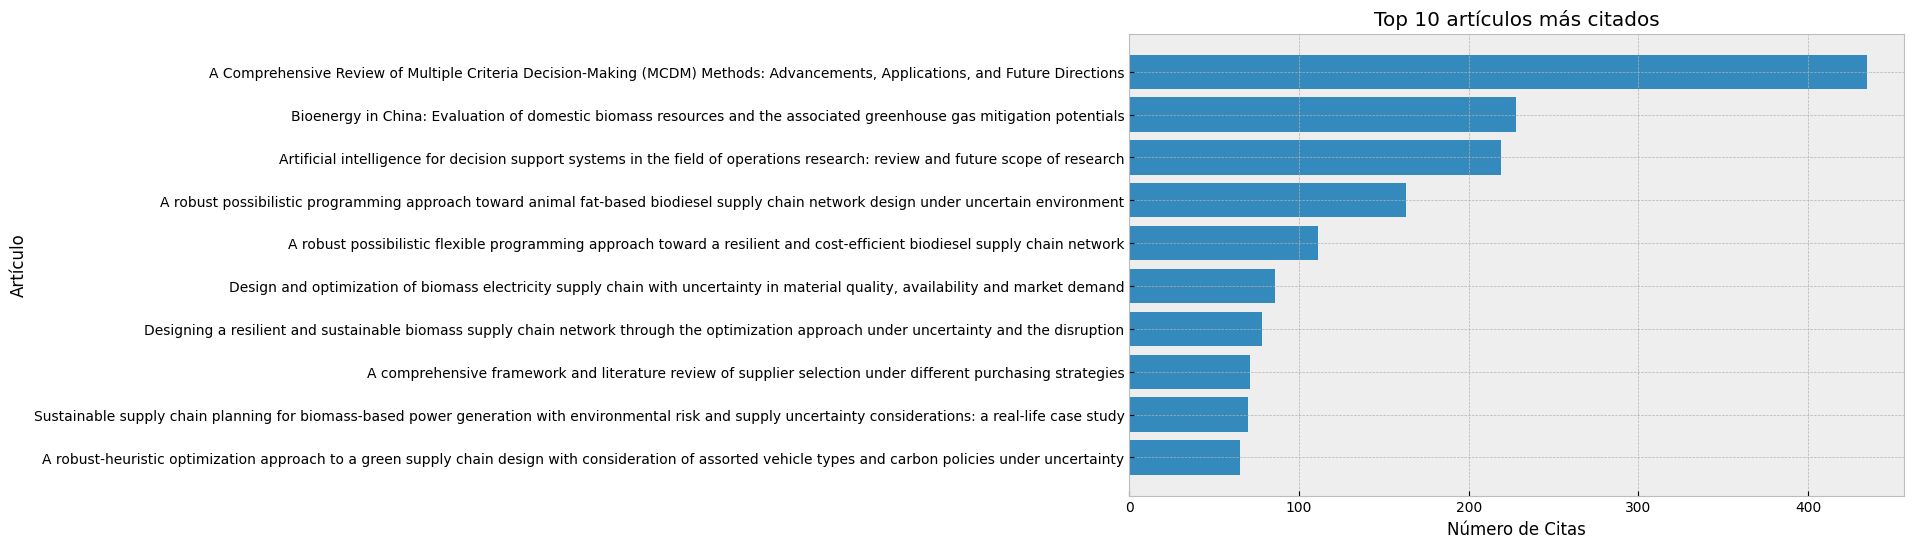

In [20]:

with open("/content/scopus1403400.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

titulos = []
citas = []

for entry in bib_database.entries:
    titulos.append(entry.get("title", "Sin título"))
    note_field = entry.get("note", "")
    match = re.search(r"Cited by:\s*(\d+)", note_field)
    citas.append(int(match.group(1)) if match else 0)

df_citas = pd.DataFrame({
    "Título": titulos,
    "Citas": citas
})

df_citas = df_citas.sort_values(by="Citas", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_citas["Título"].head(10), df_citas["Citas"].head(10))
plt.xlabel("Número de Citas")
plt.ylabel("Artículo")
plt.title("Top 10 artículos más citados")
plt.gca().invert_yaxis()
plt.show()


# **Análisis de redes de conocimiento**

*1- Colaboración entre países*

In [21]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = True, country_lst = ["colombia"])

*2- Colaboración entre autores*

In [22]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'kwa', min_count = 50, node_labels = True, label_type = 'name', centrality = 'eigen')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



In [25]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'aut', min_count = 16, node_labels = True, label_type = 'name', centrality = 'eigen')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



In [4]:
df = pd.DataFrame(bib_db.entries)

print(df.columns)

Index(['note', 'source', 'publication_stage', 'type', 'abbrev_source_title',
       'language', 'issn', 'publisher', 'correspondence_address', 'keywords',
       'author_keywords', 'abstract', 'affiliations', 'url', 'doi', 'pages',
       'number', 'volume', 'journal', 'year', 'title', 'author', 'ENTRYTYPE',
       'ID', 'coden', 'pmid'],
      dtype='object')


In [27]:
import nltk
from nltk.corpus import stopwords
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
import umap
import hdbscan

# Filtramos palabras del corpus

In [28]:

nltk.download('stopwords')
base_stop_words = list(stopwords.words('english'))

my_extra_words = [
    'biomass', 'supply', 'chain', 'model', 'optimization', 'approach', "using", "used", "use", "proposed", "propose", "considered", "considering", "shows", "paper", "research", "work",
    'results', 'problem', 'energy', 'production', "method", "methodology", "framework", "application", "case", "based", "evaluation", "results", "system", "systems", "models",
    'study', 'paper', 'analysis', "copyright", "elsevier", "springer", "wiley", "mdpi", "ieee", "doi", "http", "https", "pdf", "journal", "article", "issue", "volume",
]

final_stop_words = base_stop_words + my_extra_words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Configuramos el vectorizador

In [29]:

vectorizer_model = CountVectorizer(stop_words=final_stop_words, ngram_range=(1, 4))

# Configuramos c-TF-IDF

In [30]:
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)

# Creamos diccionario con categorias de modelos de optimización

In [58]:

categories = {
    "stochastic_programming": ["stochastic programming", "two stage stochastic", "two-stage stochastic", "multi stage stochastic", "multi-stage stochastic", "scenario based",
        "scenario-based", "recourse", "chance constrained"
    ],
    "robust_optimization": ["robust optimization", "distributionally robust", "robust model", "uncertainty set"
    ],
    "multiobjective_optimization": ["multi objective optimization", "multi-objective optimization", "pareto optimization"
    ],
    "simulation_based": ["monte carlo simulation", "monte carlo", "simulation model"
    ]
}

def analyze_optimization(text):
    text = text.lower()
    results = {}
    for cat, terms in categories.items():
        # Buscamos coincidencias
        matches = [term for term in terms if re.search(rf"\b{term}\b", text)]
        results[cat] = len(matches) > 0
    return results

df_final = bibfile.data
df_final['analysis'] = df_final['abstract'].apply(analyze_optimization)

# 4. Ver los resultados
#df_final[['title', 'analysis']].head()
#df['analysis'] = df['abstract'].apply(analyze_optimization)

# Detección de términos de optimización aplicados en los abstracks

In [59]:

all_terms = [term for sublist in categories.values() for term in sublist]

pattern = '|'.join([rf"\b{re.escape(t)}\b" for t in all_terms])

mask = df_final["abstract"].str.contains(pattern, case=False, na=False)



# Creación de embedding

In [60]:
df_opt = df_final[mask].copy().reset_index(drop=True)
docs_finales = df_opt["abstract"].tolist()

embedding_model = SentenceTransformer("allenai/scibert_scivocab_uncased")
embeddings_raw = embedding_model.encode(docs_finales, show_progress_bar=True)
embeddings_finales_np = np.array(embeddings_raw)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

# Ejecución de Bertropic

In [61]:

umap_model = umap.UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=1, metric='euclidean', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words="english", ngram_range=(1, 4))


topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    ctfidf_model=ctfidf_model,
    nr_topics=5,
    verbose=True
)


topics, probs = topic_model.fit_transform(docs_finales, embeddings_finales_np)



2026-03-18 01:19:00,840 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-18 01:19:01,176 - BERTopic - Dimensionality - Completed ✓
2026-03-18 01:19:01,178 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-18 01:19:01,198 - BERTopic - Cluster - Completed ✓
2026-03-18 01:19:01,199 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-18 01:19:01,498 - BERTopic - Representation - Completed ✓
2026-03-18 01:19:01,500 - BERTopic - Topic reduction - Reducing number of topics
2026-03-18 01:19:01,508 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-18 01:19:01,811 - BERTopic - Representation - Completed ✓
2026-03-18 01:19:01,814 - BERTopic - Topic reduction - Reduced number of topics from 12 to 5


# Creamos topicos

In [62]:
new_topics = topic_model.reduce_outliers(docs_finales, topics, probabilities=probs, strategy="probabilities")

topic_model.update_topics(docs_finales, topics=new_topics)

df_opt["topic"] = new_topics


2026-03-18 01:19:09,523 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [63]:
topic_info = topic_model.get_topic_info()

topic_info.head(15)

,Topic,Count,Name,Representation,Representative_Docs
0,0,62,0_the_of_and_to,"[the, of, and, to, in, is, supply, model, chai...",[Due to a wide variety of real-world constrain...
1,1,58,1_the_and_of_to,"[the, and, of, to, in, is, for, model, supply,...","[The growth in global population, pollution, a..."
2,2,10,2_and_the_to_of,"[and, the, to, of, biomass, in, for, that, met...",[As a potential source of low-carbon transport...
3,3,6,3_the_of_biomass_supply,"[the, of, biomass, supply, to, is, chain, micr...",[Microalgae biomass is currently gaining the l...


In [64]:
topic_model.visualize_topics()

In [65]:
topic_model.get_topic(0)

[('the', np.float64(0.12152650511708733)),
 ('of', np.float64(0.07707354124465202)),
 ('and', np.float64(0.07199707679704215)),
 ('to', np.float64(0.06221153874368813)),
 ('in', np.float64(0.04954786853251856)),
 ('is', np.float64(0.04686079096405382)),
 ('supply', np.float64(0.04328461066404004)),
 ('model', np.float64(0.04123064199943377)),
 ('chain', np.float64(0.03630277156196795)),
 ('for', np.float64(0.03055699757081864))]

In [66]:
df_opt["topic"] = topics

In [67]:
def extraer_categoria(texto, diccionario, default="not_specified"):
    if not isinstance(texto, str):
        return default

    texto = texto.lower()
    for categoria, palabras_clave in diccionario.items():
        # Usamos regex para buscar palabras completas y evitar errores
        for keyword in palabras_clave:
            if re.search(r'\b' + re.escape(keyword.lower()) + r'\b', texto):
                return categoria
    return default

# Creación de categorias de investigación

In [68]:
optimization_models = {

    "stochastic_programming": ["stochastic programming", "two stage stochastic", "two-stage stochastic", "multi stage stochastic", "multi-stage stochastic", "scenario based",
        "scenario-based", "recourse", "chance constrained"
    ],
    "robust_optimization": ["robust optimization", "distributionally robust", "robust model", "uncertainty set"
    ],
    "multiobjective_optimization": ["multi objective optimization", "multi-objective optimization", "pareto optimization"
    ],
    "simulation_based": ["monte carlo simulation", "monte carlo", "simulation model"
    ]
}



In [69]:
categories_methods = {
    "exact_methods_milp_nlp": ["linear programming", "lp", "mixed integer linear programming", "milp", "mixed integer programming", "mip", "integer programming",
        "nonlinear programming", "nlp", "mixed integer nonlinear programming", "minlp"
    ],
    "metaheuristics": ["genetic algorithm", "particle swarm optimization", "ant colony optimization", "simulated annealing", "tabu search", "evolutionary algorithm"
    ],
    "machine_learning_ann": ["machine learning", "deep learning", "neural network", "artificial neural network", "ann", "supervised learning", "unsupervised learning"
    ],
    "reinforcement_learning": ["reinforcement learning", "reinforcement agent", "reinforcement policy"
    ],
    "bayesian_frameworks": ["bayesian inference", "bayesian model", "bayesian network", "bayesian analysis", "bayesian optimization", "gaussian process", "prior distribution",
        "posterior distribution", "bayesian framework"
    ]
}

In [70]:

uncertainty_categories = {

     "supply_upstream": ["supply uncertainty", "biomass availability", "feedstock shortage", "uncertain yield", "biomass variability", "collection volume",
        "harvest window", "seasonality", "weather patterns", "crop yield"
    ],
    "feedstock_quality": ["moisture content", "calorific value", "ash content", "impurities", "feedstock quality", "heating value", "hhv", "lhv", "biomass composition"
    ],
    "logistics_transport": ["transportation time", "lead time", "delivery delay", "road closure", "logistics risk", "disruption", "resilience", "vehicle breakdown"
    ],
    "economic_market": ["price fluctuation", "cost uncertainty", "investment risk", "fuel price", "market price", "operational cost", "inflation", "exchange rate", "tariff"
    ],
    "demand_downstream": ["market requirement", "consumption", "customer needs", "uncertain demand", "stochastic demand", "demand volatility"
    ],
    "process_technical": ["biorefinery uncertainty", "conversion uncertain", "technology uncertainty", "conversion efficiency", "biorefinery yield", "technical reliability"
    ],
    "policy_environmental": ["subsidy", "carbon tax", "government policy", "incentive", "regulation", "environmental legislation", "renewable energy mandate", "feed-in tariff"
    ]
}

In [119]:
applications = {

    "strategic_network_design": ["supply chain design", "supply chain network design", "network design", "facility location", "infrastructure planning", "supply chain configuration",
        "strategic planning", "capacity planning", "location-allocation"
    ],
    "logistics_transportation": ["transportation", "biomass transportation", "logistics", "biomass logistics", "transportation planning", "transport cost", "vehicle routing", "distribution",
        "multimodal transport", "shipping", "logistic", "transport", "freight", "delivery", "shipment", "vehicle", "routing", "last-mile"
    ],
    "biorefinery_conversion": ["biorefinery", "biofuel production", "bioenergy system", "bioenergy", "biogas production", "biomass conversion", "conversion technology",
        "process yield", "biomass processing", "thermochemical conversion", "biochemical conversion", "anaerobic", "anaerobic digestion", "bioenergy conversion", "biomaterial", "biofuel conversion", "h2", "biohidrogen", "biojet"
    ],
    "inventory_storage": ["inventory management", "biomass storage", "safety stock", "stock levels", "warehousing", "storage capacity", "deterioration"
    ],
    "harvesting_collection": ["biomass harvesting", "biomass collection", "feedstock supply", "feedstock availability", "crop residue", "gathering", "field operations"
    ],
    "market_economic_analysis": ["energy market", "biofuel market", "market demand", "consumption", "consumer behavior", "market penetration", "trading", "commercialization"
    ]
}


In [143]:
sustainability = {
    "environmental": ["carbon footprint", "lca", "life cycle assessment", "emissions", "ghg", "environmental impact", "global warming"],
    "economic": ["npv", "irr", "total cost", "profitability", "economic feasibility", "payback period"],
    "social": ["job creation", "social impact", "rural development", "social acceptance", "labor safety"]
}

In [142]:
scale = {
    "spatial": ["gis", "geographic information system", "regional scale", "national scale", "global scale", "spatial analysis"],
    "temporal": ["multi-period", "multi-stage", "dynamic model", "long-term", "short-term", "daily", "monthly"]
}

In [150]:
ai_methods_vanguardia = {
    # 1. MÉTODOS TRADICIONALES (Para base de comparación)
    "Machine_Learning_Classic": ["supervised learning", "random forest", "svm", "decision tree", "regression", "knn", "gradient boosting"],

    # 2. DEEP LEARNING (La arquitectura de los picos de 3.0)
    "Deep_Learning_Architectures": ["neural network", "ann", "cnn", "lstm", "rnn", "transformer", "mlp", "deep learning"],

    # 3. IA PARA TOMA DE DECISIONES (El futuro de la logística)
    "Reinforcement_Learning": ["reinforcement learning", "q-learning", "dqn", "agent-based", "policy gradient", "multi-agent"],

    # 4. PINNs (Physics-Informed Neural Networks) - ¡Novedad en Biorrefinerías!
    # Mezcla leyes físicas con redes neuronales para que el modelo no sea "caja negra"
    "Physics_Informed_AI": ["pinn", "physics-informed", "hybrid modeling", "mechanistic-informed"],

    # 5. XAI (Explainable AI) - Crucial para la confianza del decisor
    "Explainable_AI_XAI": ["explainable ai", "xai", "shap", "lime", "interpretability", "feature importance"], "shapley additive explanations"

    # 6. GEN AI & LLMs (Lo más reciente)
    # Uso de modelos de lenguaje para análisis de políticas o generación de escenarios
    "Generative_AI_LLM": ["generative ai", "llm", "gpt", "large language model", "gan", "variational autoencoder", "langchain"],

    # 7. HYBRID OPTI-IA (Matheuristics 2.0)
    "IA_Integrated_Optimization": ["surrogate model", "meta-modeling", "ai-driven optimization", "neural optimization"]
}

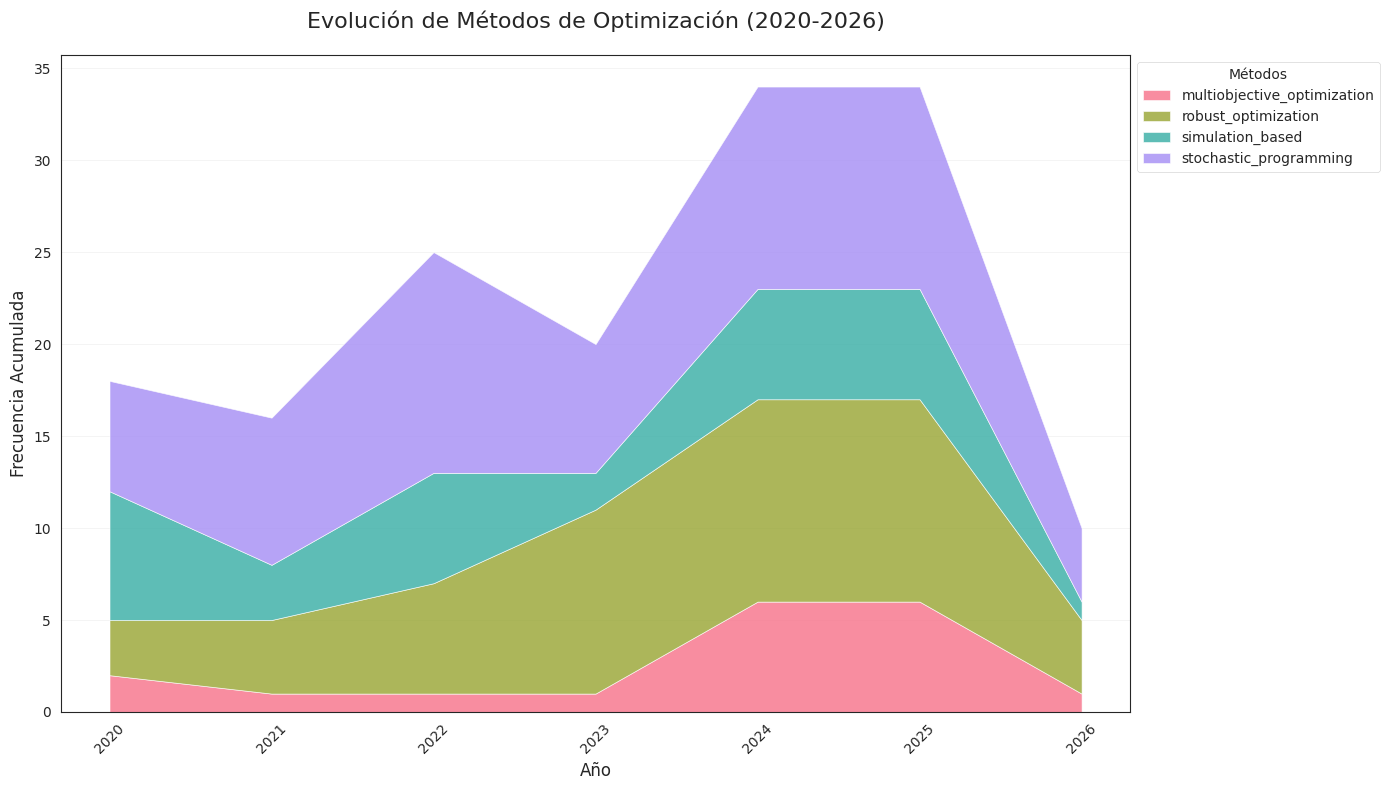

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PARTE 1: PROCESAMIENTO

df_opt['year'] = pd.to_numeric(df_opt['year'], errors='coerce')
df_opt['methods_dict'] = df_opt['abstract'].apply(analyze_optimization)
methods_df = df_opt['methods_dict'].apply(pd.Series)
df_temporal = pd.concat([df_opt[['year']], methods_df], axis=1)
df_plot = df_temporal.melt(id_vars=['year'], var_name='Method', value_name='Present')
df_plot = df_plot.dropna(subset=['year'])
df_plot = df_plot[df_plot['Present'] == True]
evolution = df_plot.groupby(['year', 'Method']).size().reset_index(name='count')

# PARTE 2: GRÁFICA

pivot_evolution = evolution.pivot(index='year', columns='Method', values='count').fillna(0)
plt.figure(figsize=(14, 8))
paleta = sns.color_palette("husl", len(pivot_evolution.columns))

plt.stackplot(
    pivot_evolution.index,
    pivot_evolution.T,
    labels=pivot_evolution.columns,
    colors=paleta,
    alpha=0.8
)

plt.title('Evolución de Métodos de Optimización (2020-2026)', fontsize=16, pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Frecuencia Acumulada', fontsize=12)
plt.legend(loc='upper left', title="Métodos", bbox_to_anchor=(1, 1))

plt.xticks(pivot_evolution.index.astype(int), rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# **Preguntas de investigación**

In [152]:

# 1. Agrupamos todos tus diccionarios en una estructura maestra
all_dicts = {
    "Models": optimization_models,
    "Methods": categories_methods,
    "Uncertainty": uncertainty_categories,
    "Applications": applications,
    "Sustainability": sustainability,
    "Scale": scale,
    "ai_methods_vanguardia": ai_methods_vanguardia
}

# 2. Función robusta de detección (Check Presence)
def check_presence_advanced(row, dictionary):
    # Unimos Título, Abstract y Keywords para no perder nada
    full_text = f"{row.get('title', '')} {row.get('abstract', '')} {row.get('keywords', '')}".lower()
    found = []
    for cat, terms in dictionary.items():
        for term in terms:
            # Búsqueda flexible: encuentra 'logistic' dentro de 'logistics'
            if term.lower() in full_text:
                found.append(cat)
                break
    return found

df_final = bibfile.data.copy()
for col_name, d_dict in all_dicts.items():
    df_final[col_name] = df_final.apply(lambda row: check_presence_advanced(row, d_dict), axis=1)

m1 = create_cooccurrence_matrix(df_final, "Applications", "Methods", applications, categories_methods)
m2 = create_cooccurrence_matrix(df_final, "Uncertainty", "Models", uncertainty_categories, optimization_models)
m3 = create_cooccurrence_matrix(df_final, "Applications", "Sustainability", applications, sustainability)

*¿Existen eslabones de la cadena de biomasa que aún no han sido abordados con técnicas de vanguardia (IA/Reinforcement Learning)?*

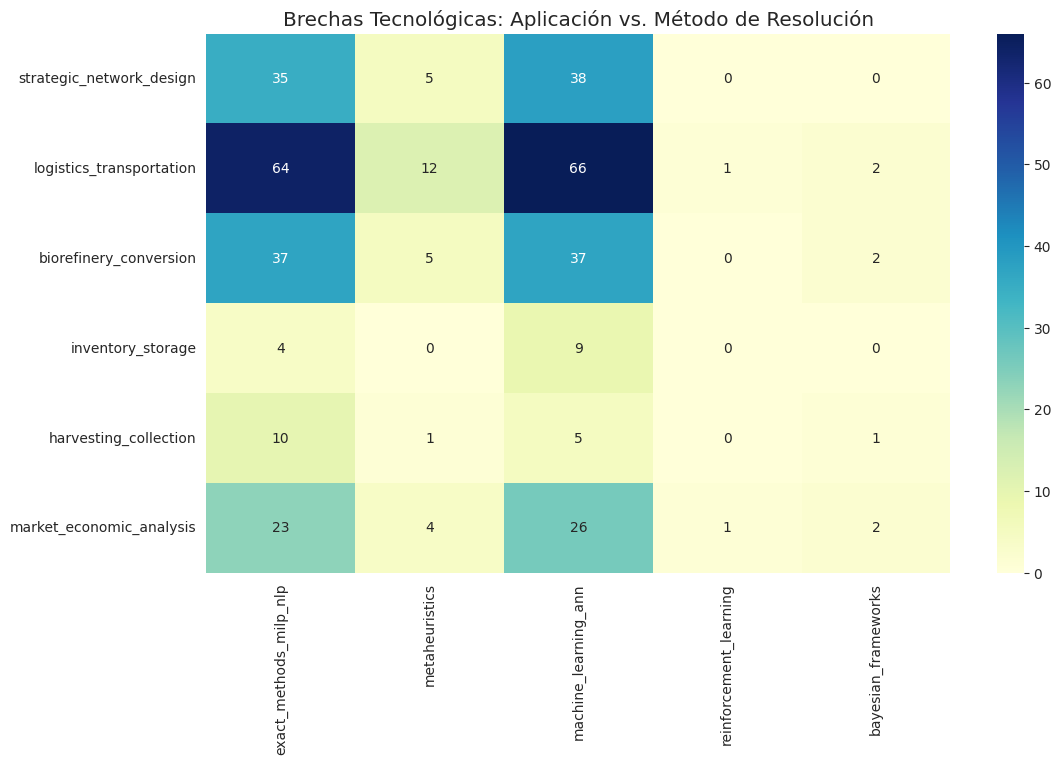

In [153]:
plt.figure(figsize=(12, 7))
sns.heatmap(m1, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Brechas Tecnológicas: Aplicación vs. Método de Resolución")
plt.show()

*¿Qué tipo de incertidumbre estamos ignorando al usar modelos determinísticos o estocásticos?*

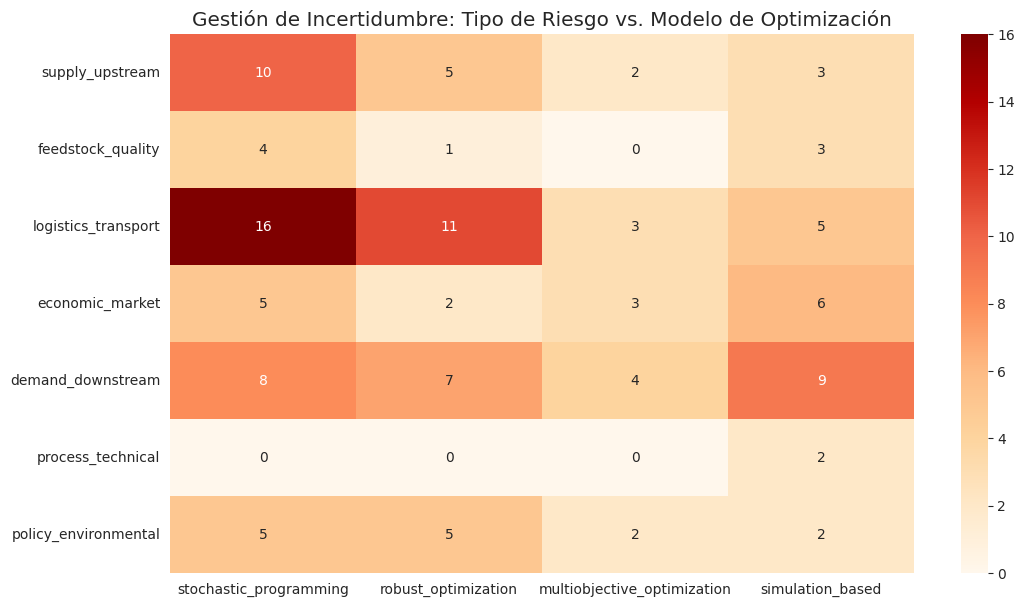

In [154]:
plt.figure(figsize=(12, 7))
sns.heatmap(m2, annot=True, fmt="d", cmap="OrRd")
plt.title("Gestión de Incertidumbre: Tipo de Riesgo vs. Modelo de Optimización")
plt.show()

*¿La investigación en logística y diseño de red es puramente económica o integra dimensiones sociales y ambientales?*

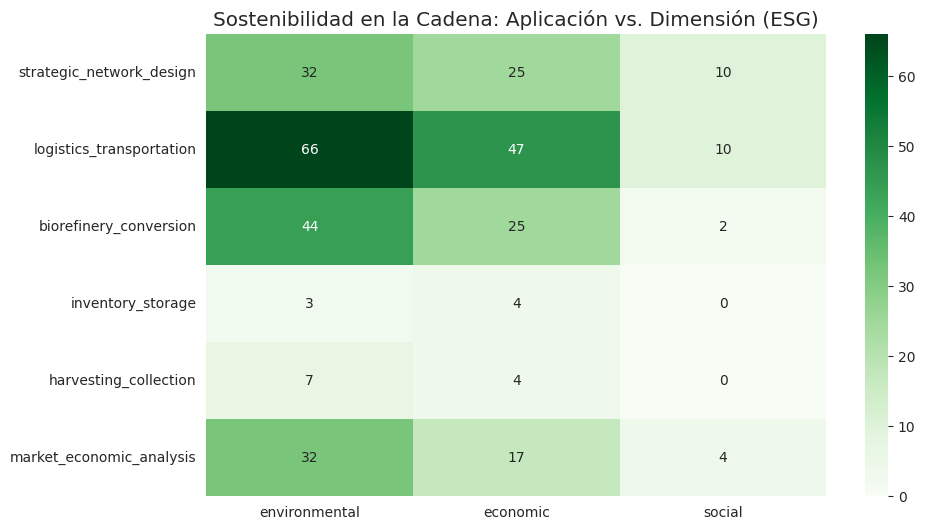

In [155]:
plt.figure(figsize=(10, 6))
sns.heatmap(m3, annot=True, fmt="d", cmap="Greens")
plt.title("Sostenibilidad en la Cadena: Aplicación vs. Dimensión (ESG)")
plt.show()

*¿Los modelos avanzados (Estocásticos/Robustos) están incorporando la complejidad espacial (GIS) y temporal necesaria para ser realistas en el mundo de la biomasa?*

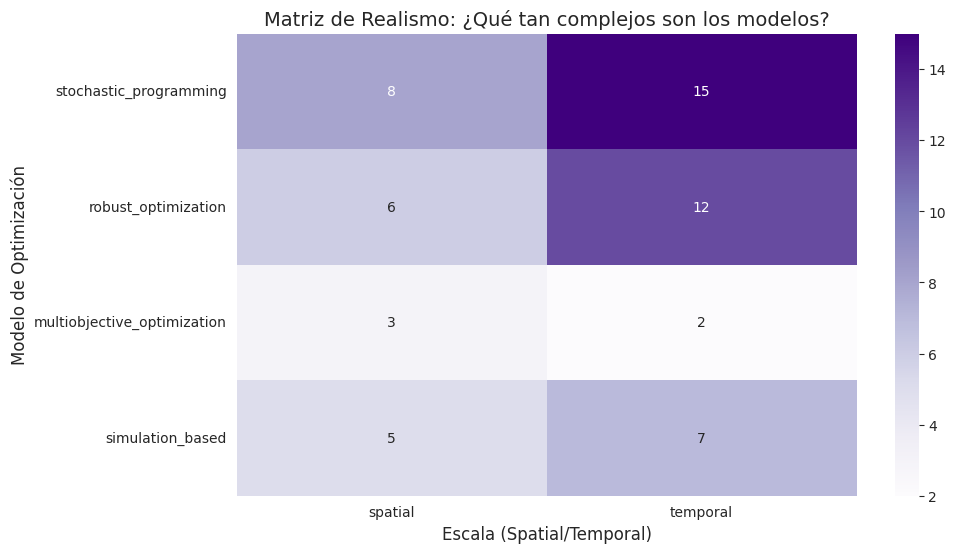

In [156]:
# Matriz de Realismo: Modelos de Optimización vs Escala (Espacial/Temporal)
m_realismo = create_cooccurrence_matrix(df_final, "Models", "Scale", optimization_models, scale)

plt.figure(figsize=(10, 6))
sns.heatmap(m_realismo, annot=True, fmt="d", cmap="Purples")
plt.title("Matriz de Realismo: ¿Qué tan complejos son los modelos?", fontsize=14)
plt.xlabel("Escala (Spatial/Temporal)")
plt.ylabel("Modelo de Optimización")
plt.show()

# Análisis: Si ves muchos ceros en el cruce de 'Stochastic' con 'Spatial',
# hay una brecha en modelos georreferenciados bajo incertidumbre.

*¿Se analiza el impacto de la incertidumbre en las dimensiones Sociales y Ambientales, o la literatura solo se protege del Riesgo Económico?*

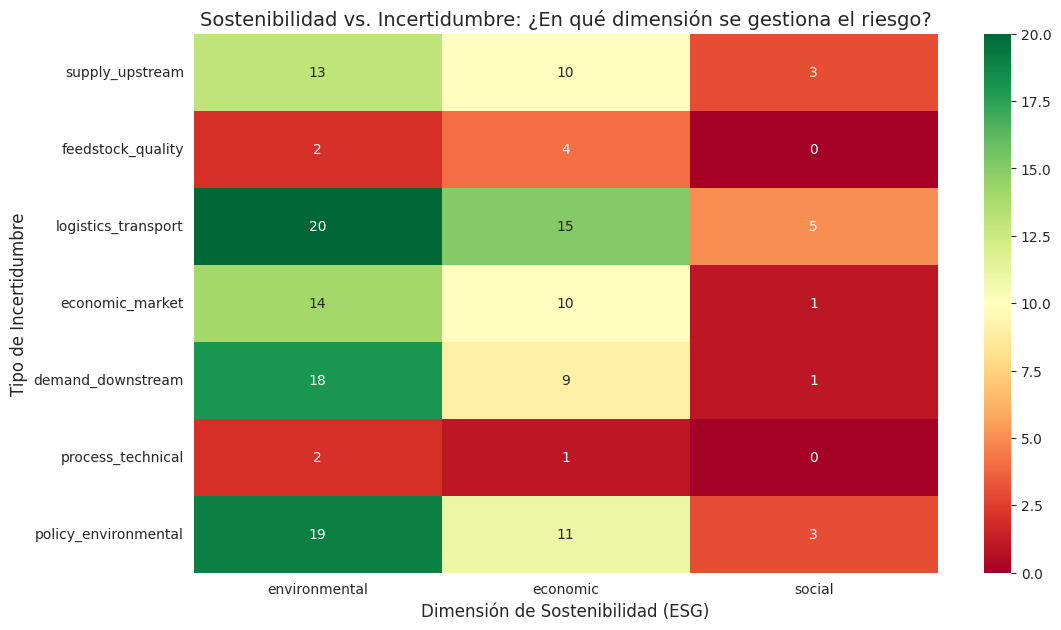

In [157]:
# Matriz de Sostenibilidad ante el Riesgo
m_sos_risk = create_cooccurrence_matrix(df_final, "Uncertainty", "Sustainability", uncertainty_categories, sustainability)

plt.figure(figsize=(12, 7))
sns.heatmap(m_sos_risk, annot=True, fmt="d", cmap="RdYlGn")
plt.title("Sostenibilidad vs. Incertidumbre: ¿En qué dimensión se gestiona el riesgo?", fontsize=14)
plt.xlabel("Dimensión de Sostenibilidad (ESG)")
plt.ylabel("Tipo de Incertidumbre")
plt.show()

# Análisis: Un vacío en la columna 'Social' indicaría que no sabemos cómo los
# cambios de clima o mercado afectan el empleo rural o el impacto social.

*¿Se están usando Metaheurísticas debido a la gran escala del problema (Nacional/Global) o se aplican incluso en problemas pequeños donde un método exacto sería mejor?*

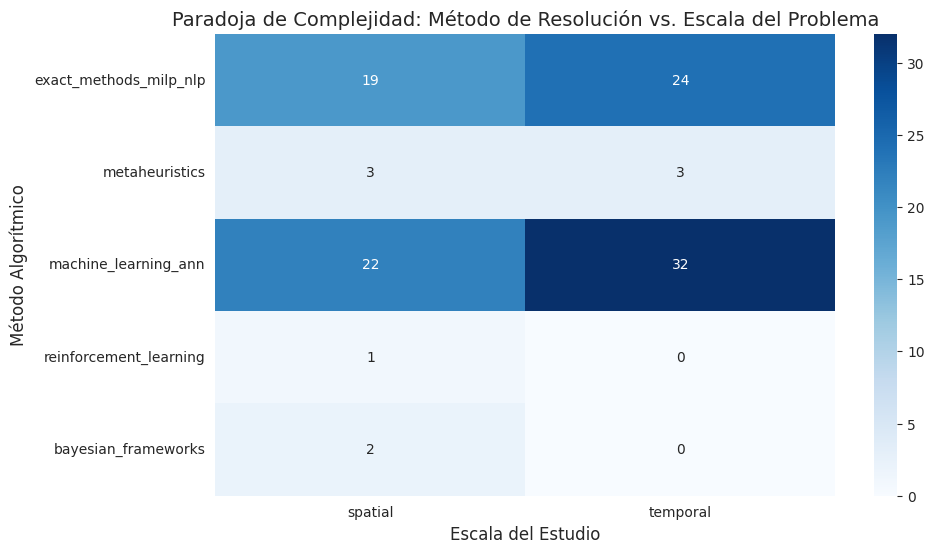

In [158]:
# Matriz de Complejidad Computacional
m_complejidad = create_cooccurrence_matrix(df_final, "Methods", "Scale", categories_methods, scale)

plt.figure(figsize=(10, 6))
sns.heatmap(m_complejidad, annot=True, fmt="d", cmap="Blues")
plt.title("Paradoja de Complejidad: Método de Resolución vs. Escala del Problema", fontsize=14)
plt.xlabel("Escala del Estudio")
plt.ylabel("Método Algorítmico")
plt.show()

# Análisis: Si 'Metaheuristics' tiene números altos en escalas pequeñas,
# podría sugerir que se usan por preferencia y no por necesidad computacional.

*¿Tenemos una "herramienta favorita" para cada riesgo? ¿La calidad de la biomasa se optimiza o solo se simula?*

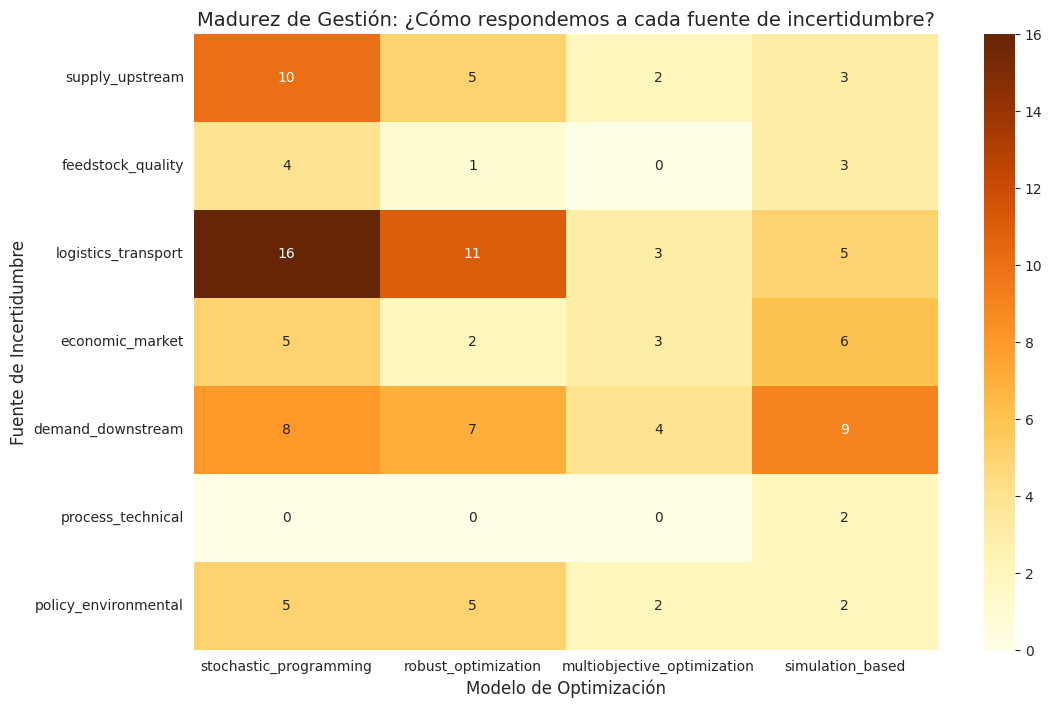

In [159]:
# Matriz de Madurez: Incertidumbre Específica vs Modelos de Optimización
m_madurez = create_cooccurrence_matrix(df_final, "Uncertainty", "Models", uncertainty_categories, optimization_models)

plt.figure(figsize=(12, 8))
sns.heatmap(m_madurez, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Madurez de Gestión: ¿Cómo respondemos a cada fuente de incertidumbre?", fontsize=14)
plt.xlabel("Modelo de Optimización")
plt.ylabel("Fuente de Incertidumbre")
plt.show()

# Análisis: Si 'Feedstock Quality' solo tiene cruces con 'Simulation', significa
# que la literatura aún no logra integrar la calidad en modelos de decisión matemática.

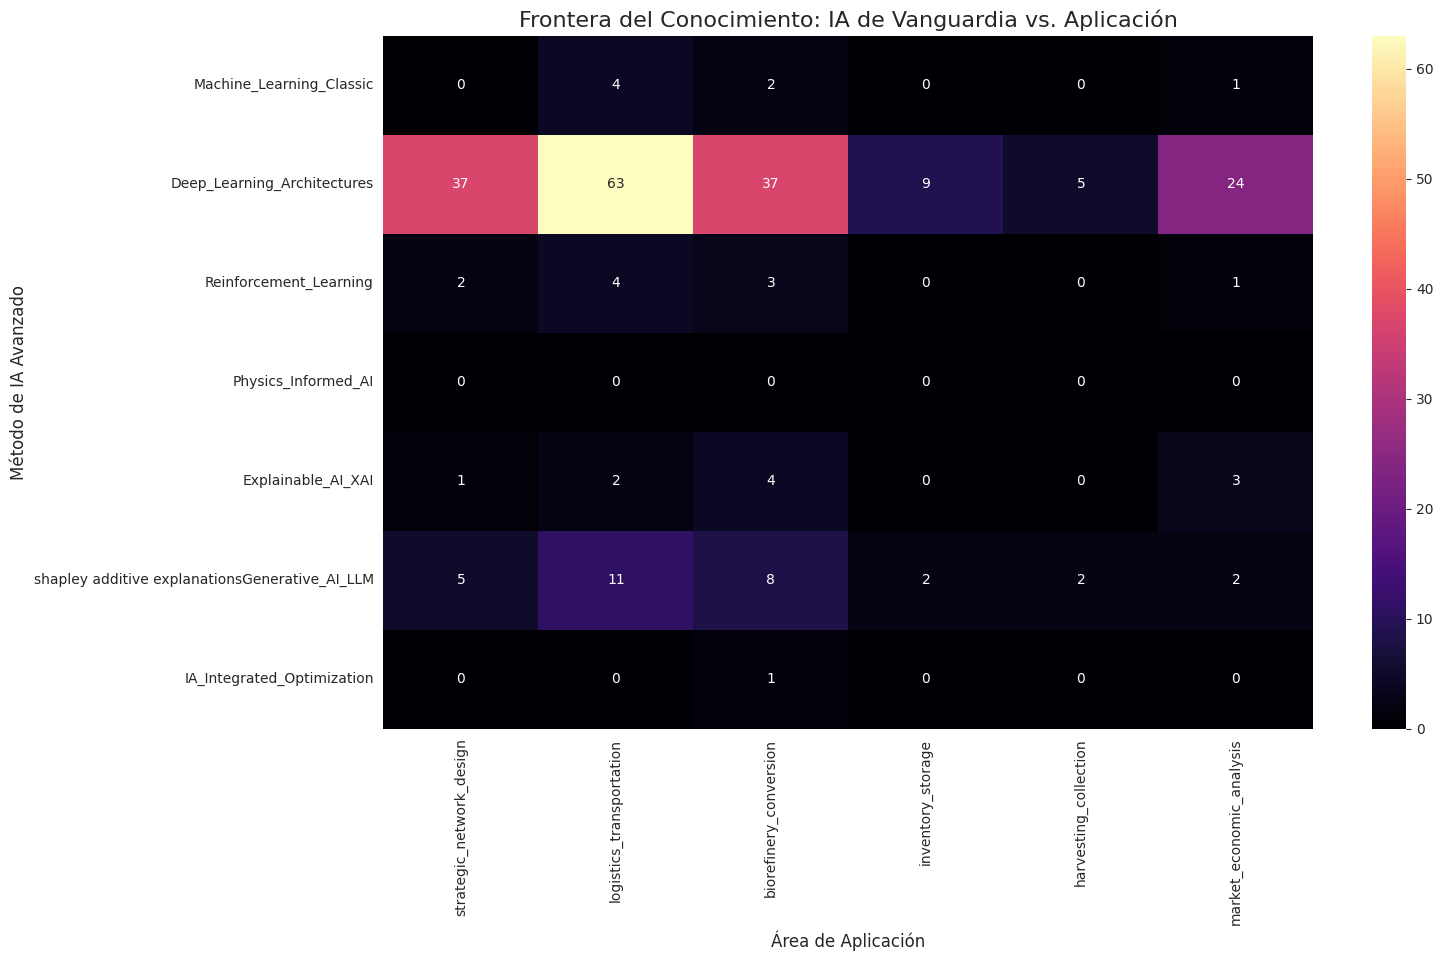

In [163]:
def create_heatmap_advanced(df, col_fila, col_columna, dict_fila, dict_columna):
    """
    Crea una matriz de co-ocurrencia para columnas que contienen listas de etiquetas.
    """
    # Inicializamos la matriz con ceros usando las llaves de los diccionarios
    matrix = pd.DataFrame(0, index=dict_fila.keys(), columns=dict_columna.keys())

    for _, row in df.iterrows():
        # Extraemos las listas de etiquetas (asegurando que sean iterables)
        filas = row.get(col_fila, [])
        columnas = row.get(col_columna, [])

        # Si no son listas (un solo string), las convertimos
        if isinstance(filas, str): filas = [filas]
        if isinstance(columnas, str): columnas = [columnas]

        for f in filas:
            for c in columnas:
                if f in matrix.index and c in matrix.columns:
                    matrix.loc[f, c] += 1
    return matrix

# 1. Aplicamos el diccionario de vanguardia
df_final['AI_Vanguardia'] = df_final.apply(lambda row: check_presence_advanced(row, ai_methods_vanguardia), axis=1)

# 2. Creamos la matriz cruzando con Aplicaciones
m_vanguardia = create_heatmap_advanced(df_final, "AI_Vanguardia", "Applications", ai_methods_vanguardia, applications)

# 3. Graficamos
plt.figure(figsize=(15, 9))
sns.heatmap(m_vanguardia, annot=True, fmt="d", cmap="magma")
plt.title("Frontera del Conocimiento: IA de Vanguardia vs. Aplicación", fontsize=16)
plt.xlabel("Área de Aplicación")
plt.ylabel("Método de IA Avanzado")
plt.show()

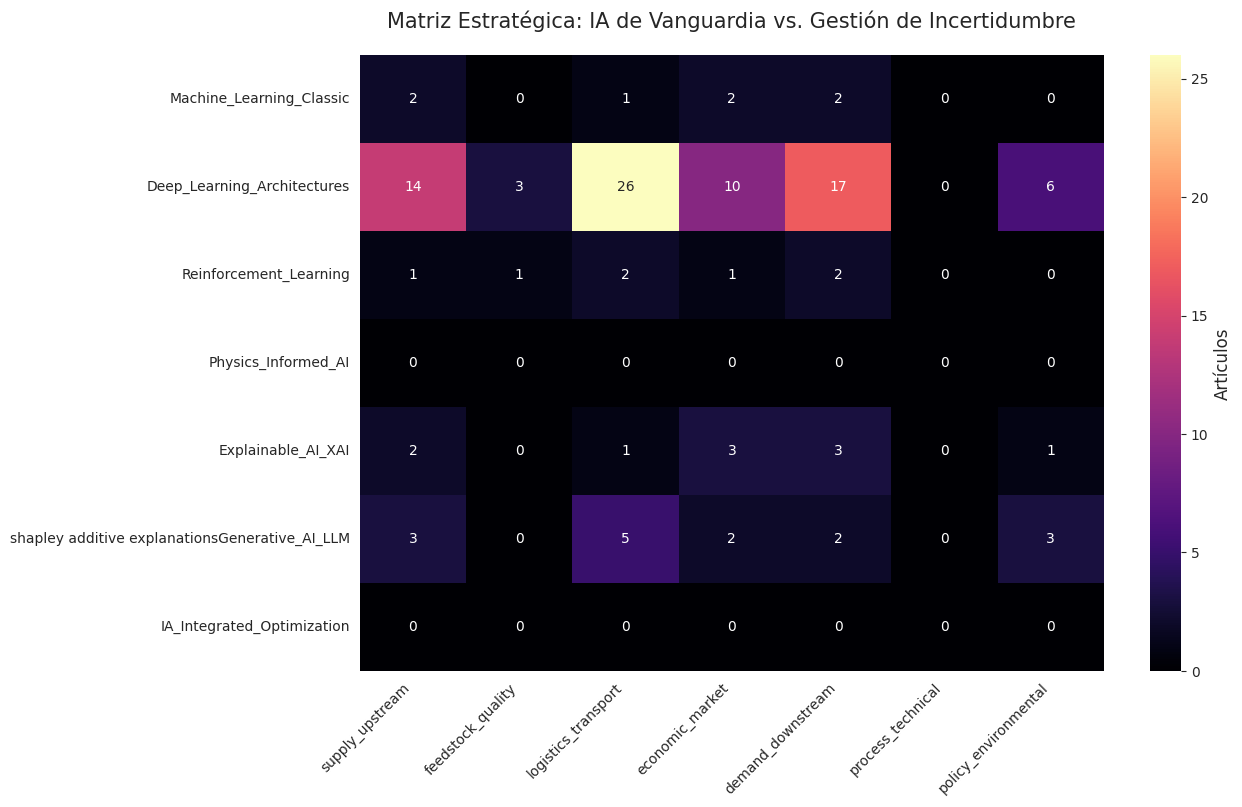

In [167]:

# 1. Función de creación de matriz optimizada para 7 diccionarios (Multietiqueta)
def create_cooccurrence_matrix_v3(df, col_row, col_col, dict_row, dict_col):
    # Creamos el dataframe vacío con los índices y columnas correctos
    matrix = pd.DataFrame(0, index=dict_row.keys(), columns=dict_col.keys())

    for _, row in df.iterrows():
        # Extraemos las listas de etiquetas de cada columna
        labels_row = row.get(col_row, [])
        labels_col = row.get(col_col, [])

        # Cruzamos cada etiqueta encontrada
        for r in labels_row:
            for c in labels_col:
                if r in matrix.index and c in matrix.columns:
                    matrix.loc[r, c] += 1
    return matrix

# 2. GENERACIÓN DE MATRICES (Las 3 clásicas + las nuevas de IA)

# Matriz 1: Aplicaciones vs Métodos Tradicionales
m1 = create_cooccurrence_matrix_v3(df_final, "Applications", "Methods", applications, categories_methods)

# Matriz 2: Incertidumbre vs Modelos de Optimización
m2 = create_cooccurrence_matrix_v3(df_final, "Uncertainty", "Models", uncertainty_categories, optimization_models)

# Matriz 3: Aplicaciones vs Sostenibilidad
m3 = create_cooccurrence_matrix_v3(df_final, "Applications", "Sustainability", applications, sustainability)

# --- NUEVAS MATRICES CON EL 7mo DICCIONARIO (IA Vanguardia) ---

# Matriz 4: IA de Vanguardia vs Aplicaciones (¿Dónde se aplica cada IA?)
m4 = create_cooccurrence_matrix_v3(df_final, "ai_methods_vanguardia", "Applications", ai_methods_vanguardia, applications)

# Matriz 5: IA de Vanguardia vs Incertidumbre (¿Qué IA resuelve qué riesgo?)
m5 = create_cooccurrence_matrix_v3(df_final, "ai_methods_vanguardia", "Uncertainty", ai_methods_vanguardia, uncertainty_categories)

# 3. Función para graficar cualquier matriz rápidamente
def plot_matrix(matrix, title, color="YlGnBu"):
    plt.figure(figsize=(12, 8))
    sns.heatmap(matrix, annot=True, fmt="d", cmap=color, cbar_kws={'label': 'Artículos'})
    plt.title(title, fontsize=15, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Ejemplo: Graficar la nueva matriz de IA vs Incertidumbre
plot_matrix(m5, "Matriz Estratégica: IA de Vanguardia vs. Gestión de Incertidumbre", "magma")

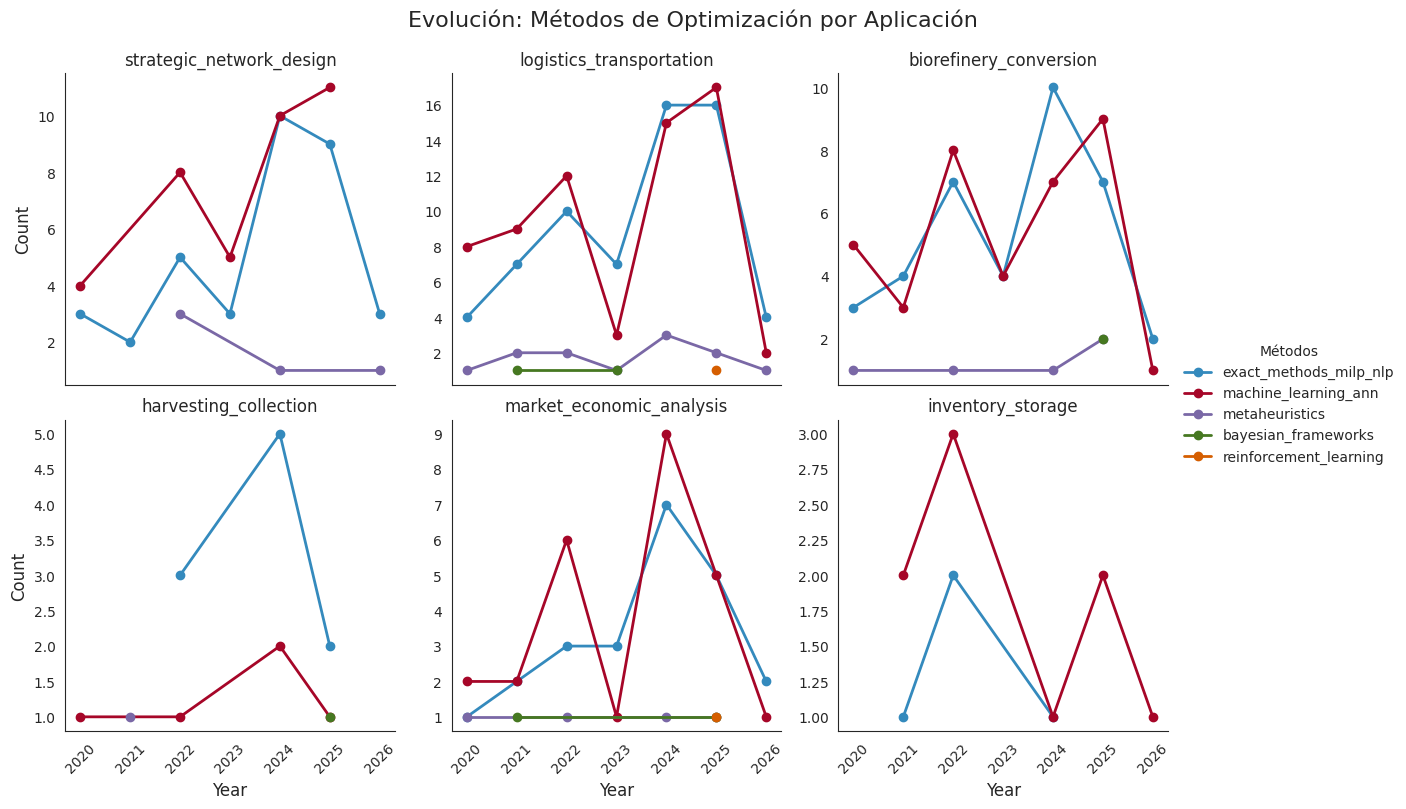

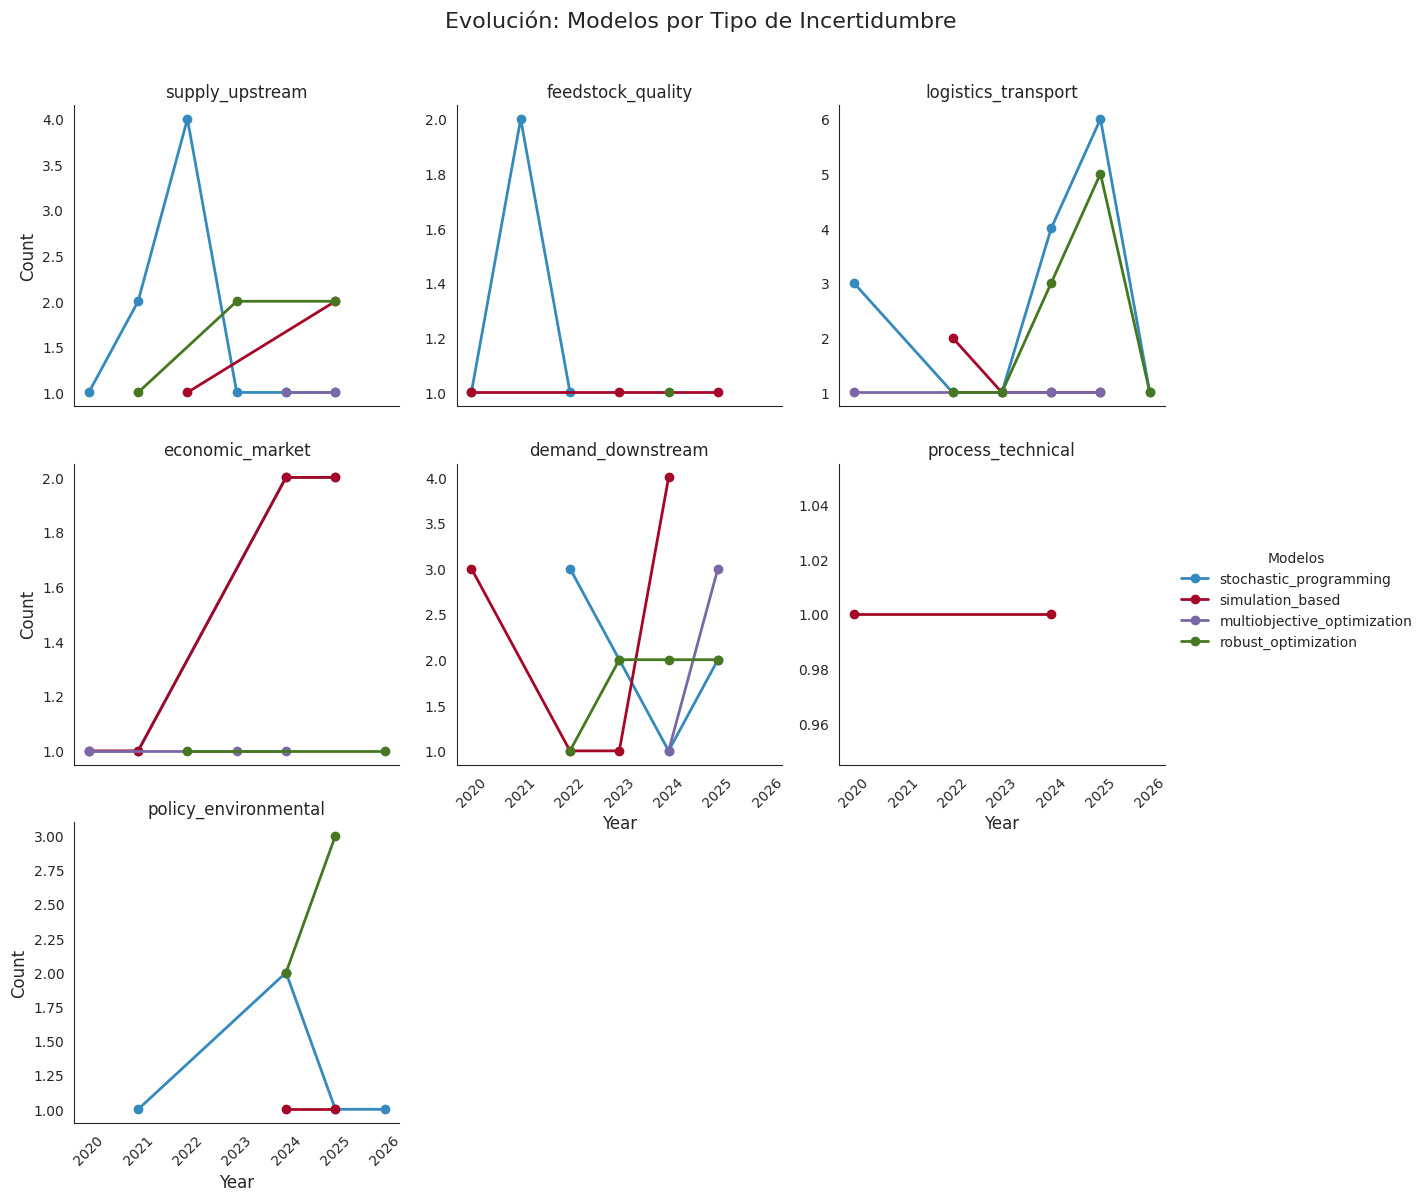

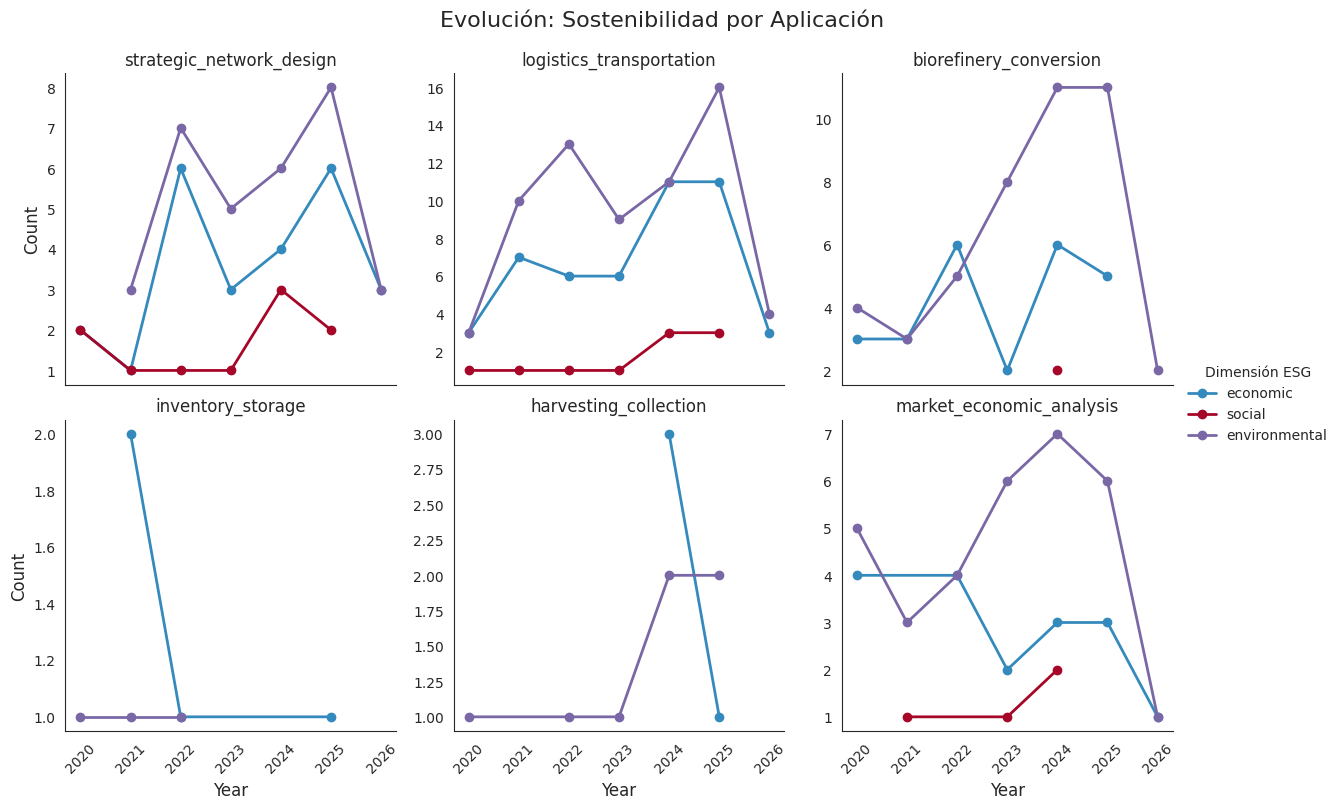

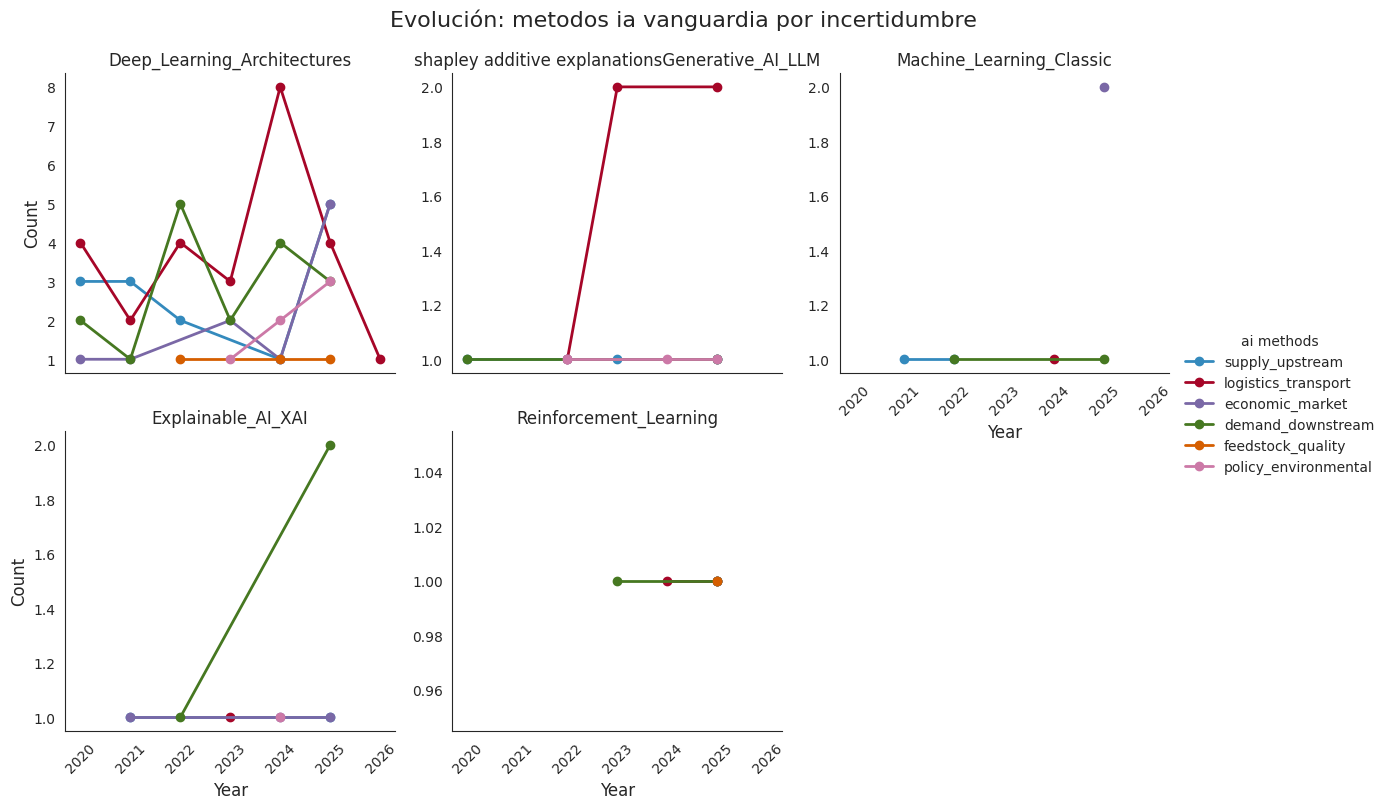

In [170]:
# 1. Función de detección mejorada (Busca en Título + Abstract + Keywords)
def check_presence_advanced(row, dictionary):
    # Combinamos todos los campos de texto disponibles
    text_fields = [row.get('title', ''), row.get('abstract', ''), row.get('keywords', '')]
    full_text = " ".join([str(f) for f in text_fields]).lower()

    found_categories = []
    for category, terms in dictionary.items():
        for term in terms:
            # Quitamos \b para permitir plurales y derivaciones (ej: 'logistic' hallará 'logistics')
            if term.lower() in full_text:
                found_categories.append(category)
                break # Evita contar la misma categoría dos veces para el mismo artículo
    return found_categories

# 2. Procesamiento de la base de datos completa
df_final = bibfile.data.copy()

# Diccionario maestro para el loop
all_dicts = {
    "Models": optimization_models,
    "Methods": categories_methods,
    "Uncertainty": uncertainty_categories,
    "Applications": applications,
    "Sustainability": sustainability,
    "Scale": scale,
    "ai_methods_vanguardia": ai_methods_vanguardia
}

# Aplicamos la búsqueda avanzada
for col_name, d_dict in all_dicts.items():
    df_final[col_name] = df_final.apply(lambda row: check_presence_advanced(row, d_dict), axis=1)

# Preparación temporal
df_final['year'] = pd.to_numeric(df_final['year'], errors='coerce')
df_temporal = df_final[df_final['year'] >= 2018].dropna(subset=['year'])
df_temporal['year'] = df_temporal['year'].astype(int)

# 3. Función de procesamiento para Series Temporales
def get_timeseries_data_v2(df, col_main, col_sub, dict_main, dict_sub):
    time_data = []
    years = sorted(df['year'].unique())

    for year in years:
        df_year = df[df['year'] == year]
        for cat in dict_main.keys():
            # Filtramos artículos que pertenecen a la categoría principal
            df_cat = df_year[df_year[col_main].apply(lambda x: cat in x)]

            if not df_cat.empty:
                counts = {sub: 0 for sub in dict_sub.keys()}
                for _, row in df_cat.iterrows():
                    for sub in row[col_sub]:
                        if sub in counts: counts[sub] += 1

                for sub, count in counts.items():
                    if count > 0:
                        time_data.append({'Year': year, 'Category': cat, 'Subcategory': sub, 'Count': count})
    return pd.DataFrame(time_data)

# 4. Generación de datos para los 3 análisis
ts1 = get_timeseries_data_v2(df_temporal, "Applications", "Methods", applications, categories_methods)
ts2 = get_timeseries_data_v2(df_temporal, "Uncertainty", "Models", uncertainty_categories, optimization_models)
ts3 = get_timeseries_data_v2(df_temporal, "Applications", "Sustainability", applications, sustainability)
ts4 = get_timeseries_data_v2(df_temporal, "ai_methods_vanguardia", "Uncertainty", ai_methods_vanguardia, uncertainty_categories )

# 5. Visualización de Tendencias (Matriz 1: Apps vs Methods)
def plot_trends(df, title, hue_label):
    if df.empty:
        print(f"Sin datos para: {title}")
        return
    g = sns.FacetGrid(df, col="Category", hue="Subcategory", col_wrap=3, height=4, sharey=False)
    g.map(plt.plot, "Year", "Count", marker="o", linewidth=2)
    g.add_legend(title=hue_label)
    g.set_titles("{col_name}")
    for ax in g.axes.flat:
        ax.set_xticks(df['Year'].unique())
        ax.set_xticklabels(df['Year'].unique(), rotation=45)
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(title, fontsize=16)
    plt.show()

plot_trends(ts1, 'Evolución: Métodos de Optimización por Aplicación', 'Métodos')
plot_trends(ts2, 'Evolución: Modelos por Tipo de Incertidumbre', 'Modelos')
plot_trends(ts3, 'Evolución: Sostenibilidad por Aplicación', 'Dimensión ESG')
plot_trends(ts4, 'Evolución: metodos ia vanguardia por incertidumbre', 'ai methods')

# **Primer hallazgo: Métodos vs Incertidumbres**

In [81]:
import pandas as pd
import re

def extraer_robusto(texto, diccionario, nombre_defecto):
    if not isinstance(texto, str): return nombre_defecto
    texto = texto.lower()
    for categoria, keywords in diccionario.items():
        for key in keywords:
            if re.search(r'\b' + re.escape(key.lower()) + r'\b', texto):
                return categoria
    return nombre_defecto

df_matrix_completa = pd.DataFrame()

df_matrix_completa['method'] = df_opt['abstract'].apply(
    lambda x: extraer_robusto(x, optimization_models, "other/not_defined")
)
df_matrix_completa['uncertainty'] = df_opt['abstract'].apply(
    lambda x: extraer_robusto(x, uncertainty_categories, "deterministic")
)
df_matrix_completa['application'] = df_opt['abstract'].apply(
    lambda x: extraer_robusto(x, applications, "general_biomass")
)

print(f"Total de documentos en la nueva matriz: {len(df_matrix_completa)}")

resumen = pd.crosstab(df_matrix_completa.method, df_matrix_completa.uncertainty)
print(resumen)

Total de documentos en la nueva matriz: 136
uncertainty                  demand_downstream  deterministic  \
method                                                          
multiobjective_optimization                  1              9   
robust_optimization                          1             27   
simulation_based                             3              8   
stochastic_programming                       5             35   

uncertainty                  economic_market  feedstock_quality  \
method                                                            
multiobjective_optimization                1                  0   
robust_optimization                        0                  1   
simulation_based                           5                  2   
stochastic_programming                     1                  3   

uncertainty                  logistics_transport  policy_environmental  \
method                                                                   
multiobjective

In [82]:

df_matrix_completa = df_matrix_completa.fillna("not_defined").astype(str) # Convertimos todo a string y llenamos los vacíos reales

df_matrix_completa = df_matrix_completa.apply(lambda x: x.str.strip()) # Limpiamos posibles espacios en blanco que arruinan el conteo

Documentos en la nueva variable: 136


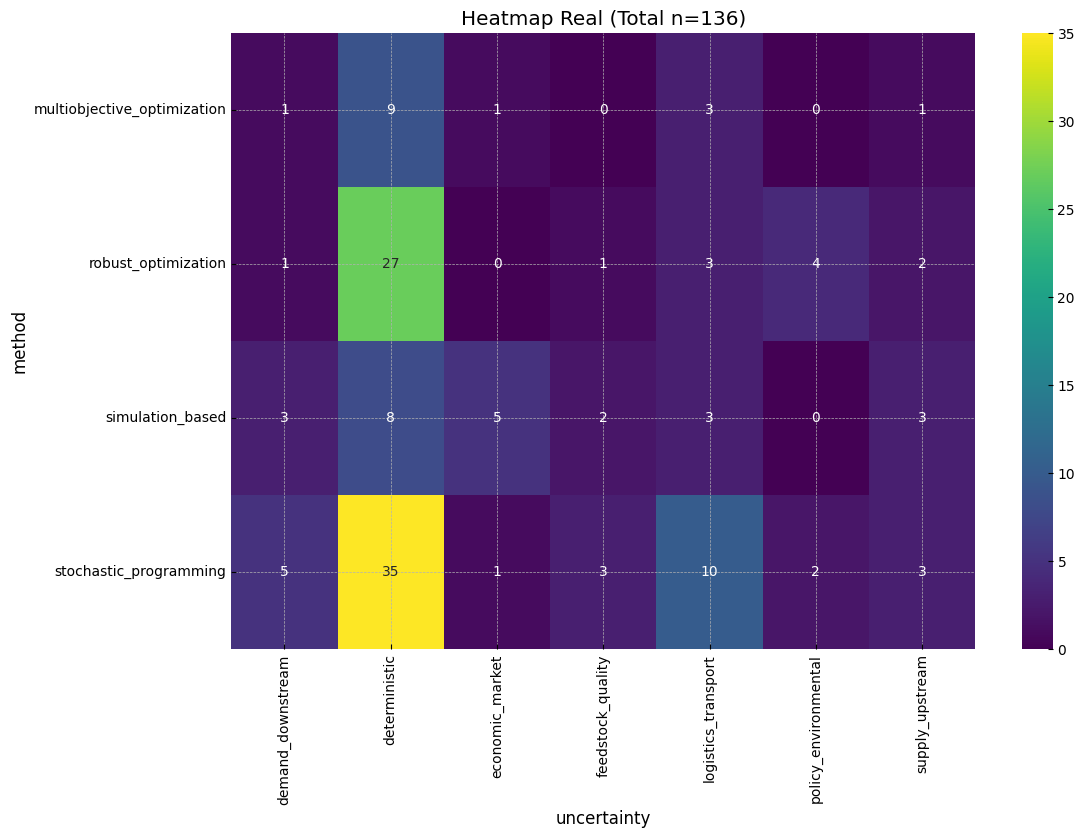

In [84]:
df_RESCATE_TOTAL = pd.DataFrame()

df_RESCATE_TOTAL['method'] = df_opt['abstract'].apply(
    lambda x: extraer_robusto(x, optimization_models, "other/not_defined")
)
df_RESCATE_TOTAL['uncertainty'] = df_opt['abstract'].apply(
    lambda x: extraer_robusto(x, uncertainty_categories, "deterministic")
)

print(f"Documentos en la nueva variable: {len(df_RESCATE_TOTAL)}")

tabla_final = pd.crosstab(df_RESCATE_TOTAL['method'], df_RESCATE_TOTAL['uncertainty'])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(tabla_final, annot=True, fmt="d", cmap="viridis")
plt.title(f"Heatmap Real (Total n={tabla_final.values.sum()})")
plt.show()

# **Segundo hallazgo: Método vs objetivo buscado**

In [85]:
objective_dict = {
    "Economic": ["cost", "profit", "revenue", "npv", "economic", "financial", "capex", "opex", "roi"],

    "Environmental": ["emission", "ghg", "carbon", "environmental", "lca", "pollution", "footprint", "gwp", "sustainability"],

    "Social": ["jobs", "social", "employment", "stakeholder", "community", "safety", "local development"],

    "Technical_Service": ["demand fulfillment", "distance", "lead time", "reliability", "efficiency", "inventory level", "service level"],

    "Resilience_Risk": ["resilience", "risk", "cvar", "robustness", "disruption recovery", "variability reduction"],

    "Resource_Circular": ["circularity", "waste", "water footprint", "land use", "recycling", "resource depletion"]
}

df_matrix_completa['objective'] = df_opt['abstract'].apply(
    lambda x: extraer_robusto(x, objective_dict, "objective_not_stated")
)

In [86]:
df_matrix_completa

,method,uncertainty,application,objective
0,simulation_based,deterministic,strategic_network_design,Economic
1,robust_optimization,policy_environmental,strategic_network_design,Economic
2,stochastic_programming,logistics_transport,logistics_transportation,Environmental
3,stochastic_programming,deterministic,market_economic_analysis,Economic
4,multiobjective_optimization,deterministic,strategic_network_design,Economic
...,...,...,...,...
131,stochastic_programming,deterministic,strategic_network_design,Economic
132,simulation_based,deterministic,general_biomass,Social
133,robust_optimization,deterministic,biorefinery_conversion,Economic
134,simulation_based,feedstock_quality,biorefinery_conversion,Economic


In [87]:

df_matrix_completa['objective'] = df_matrix_completa['objective'].fillna('Not Stated')

resumen_objetivos = pd.crosstab(
    df_matrix_completa['method'],
    df_matrix_completa['objective'],
    dropna=False
)

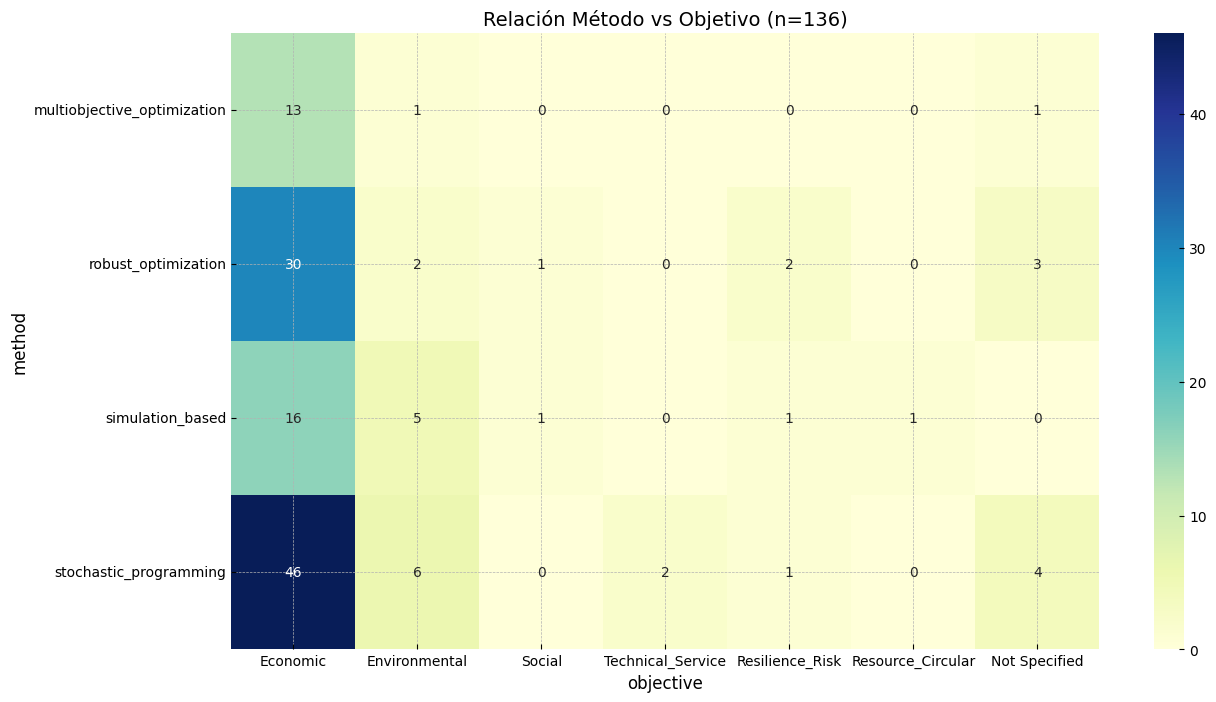

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aseguramos que nada sea nulo y convertimos a 'Not Specified' lo que no se detectó
df_matrix_completa['objective'] = df_matrix_completa['objective'].fillna('Not Specified')
df_matrix_completa['objective'] = df_matrix_completa['objective'].replace('objective_not_stated', 'Not Specified')

columnas_interes = ['Economic', 'Environmental', 'Social', 'Technical_Service', 'Resilience_Risk', "Resource_Circular", 'Not Specified']

resumen_objetivos = pd.crosstab(df_matrix_completa['method'], df_matrix_completa['objective'])

resumen_objetivos = resumen_objetivos.reindex(columns=columnas_interes, fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(resumen_objetivos, annot=True, fmt="d", cmap="YlGnBu")

plt.title(f'Relación Método vs Objetivo (n={resumen_objetivos.values.sum()})', fontsize=14)
plt.show()

# **Creación de tablas con base a co-ocurrencia**

In [89]:
documents = df_opt["abstract"].tolist()

In [93]:
import pandas as pd

records = []

for text in documents:

    methods_found = []
    uncertainty_found = []
    applications_found = []

    text = text.lower()


    for method, keywords in optimization_methods.items():
        for k in keywords:
            if k in text:
                methods_found.append(method)


    for utype, keywords in uncertainty_categories.items():
        for k in keywords:
            if k in text:
                uncertainty_found.append(utype)


    for app, keywords in applications.items():
        for k in keywords:
            if k in text:
                applications_found.append(app)

    for m in methods_found:
        for u in uncertainty_found:
            for a in applications_found:

                records.append({
                    "method":m,
                    "uncertainty":u,
                    "application":a
                })

In [94]:
df_matrix_completa = pd.DataFrame(records)

df_matrix_completa.head()

,method,uncertainty,application
0,robust_optimization,policy_environmental,strategic_network_design
1,robust_optimization,policy_environmental,biorefinery_conversion
2,robust_optimization,policy_environmental,inventory_storage
3,robust_optimization,policy_environmental,harvesting_collection
4,stochastic_programming,logistics_transport,logistics_transportation


In [95]:
method_uncertainty = pd.crosstab(
    df_matrix_completa.method,
    df_matrix_completa.uncertainty
)

method_uncertainty

uncertainty,demand_downstream,economic_market,feedstock_quality,logistics_transport,policy_environmental,process_technical,supply_upstream
method,,,,,,,
machine_learning,0,2,6,0,0,0,3
mathematical_programming,3,6,14,14,8,0,16
metaheuristics,0,0,4,1,6,0,2
multiobjective_optimization,5,4,0,4,5,0,2
robust_optimization,16,3,0,37,10,0,0
simulation,32,17,22,15,1,6,24
stochastic_programming,13,9,24,68,11,0,10


In [96]:
pivot_table = pd.pivot_table(
    df_matrix_completa,
    index="method",
    columns=["application", "uncertainty"],
    aggfunc=len,
    fill_value=0
)

pivot_table

application                 biorefinery_conversion                  \
uncertainty                      demand_downstream economic_market   
method                                                               
machine_learning                                 0               0   
mathematical_programming                         1               1   
metaheuristics                                   0               0   
multiobjective_optimization                      0               1   
robust_optimization                              2               1   
simulation                                       9               4   
stochastic_programming                           0               3   

application                                                        \
uncertainty                 feedstock_quality logistics_transport   
method                                                              
machine_learning                            2                   0   
mathematical_programming                    6                   2   
metaheuristics                              3                   1   
multiobjective_optimization                 0                   0   
robust_optimization                         0                   3   
simulation                                 12                   4   
stochastic_programming                      8                   1   

application                                                         \
uncertainty                 policy_environmental process_technical   
method                                                               
machine_learning                               0                 0   
mathematical_programming                       2                 0   
metaheuristics                                 0                 0   
multiobjective_optimization                    2                 0   
robust_optimization                            3                 0   
simulation                                     0                 4   
stochastic_programming                         2                 0   

application                                 harvesting_collection  \
uncertainty                 supply_upstream       economic_market   
method                                                              
machine_learning                          1                     0   
mathematical_programming                  5                     0   
metaheuristics                            1                     0   
multiobjective_optimization               1                     0   
robust_optimization                       0                     0   
simulation                                2                     0   
stochastic_programming                    4                     1   

application                                                        ...  \
uncertainty                 feedstock_quality logistics_transport  ...   
method                                                             ...   
machine_learning                            0                   0  ...   
mathematical_programming                    0                   3  ...   
metaheuristics                              0                   0  ...   
multiobjective_optimization                 0                   0  ...   
robust_optimization                         0                   0  ...   
simulation                                  0                   0  ...   
stochastic_programming                      4                   2  ...   

application                 market_economic_analysis                      \
uncertainty                          economic_market logistics_transport   
method                                                                     
machine_learning                                   0                   0   
mathematical_programming                           1                   0   
metaheuristics                                     0                   0   
multiobjective_opti

# **Tercer hallazgo: Nivel de decisión vs incertidumbre**

In [97]:
import pandas as pd
import re

decision_categories = {
    "facility_location": ["location", "siting", "network design", "warehouse", "allocation", "strategic design"],
    "pretreatment": ["pretreatment", "drying", "pelletization", "torrefaction", "anaerobic", "biochemical", "mechanical", "chemical", "densification", "grinding", "briquetting", "pyrolysis", "gasification"],
    "logistics_routing": ["routing", "vehicle routing", "vrp", "scheduling", "fleet", "transportation", "last-mile", "transportation planning"],
    "inventory_mgt": ["inventory", "stock", "storage", "buffer", "safety stock"],
    "capacity_planning": ["capacity expansion", "scaling", "modular design", "investment"]
}

def extraer_todas(texto, diccionario):
    if not isinstance(texto, str): return ["not_defined"]
    texto = texto.lower()
    encontradas = []
    for categoria, keywords in diccionario.items():
        for key in keywords:
            if re.search(r'\b' + re.escape(key.lower()) + r'\b', texto):
                encontradas.append(categoria)
                break # Pasa a la siguiente categoría si ya encontró una keyword
    return encontradas if encontradas else ["not_defined"]

df_decisiones = pd.DataFrame()
df_decisiones['abstract'] = df_opt['abstract']

df_decisiones['dec_list'] = df_opt['abstract'].apply(lambda x: extraer_todas(x, decision_categories))
df_decisiones['unc_list'] = df_opt['abstract'].apply(lambda x: extraer_todas(x, uncertainty_categories))

df_exploded = df_decisiones.explode('dec_list').explode('unc_list')

matriz_dec_inc = pd.crosstab(df_exploded['dec_list'], df_exploded['unc_list'])

print("Matriz Decisiones vs Incertidumbres generada.")
print(matriz_dec_inc)

Matriz Decisiones vs Incertidumbres generada.
unc_list           demand_downstream  economic_market  feedstock_quality  \
dec_list                                                                   
capacity_planning                  4                1                  1   
facility_location                  5                0                  1   
inventory_mgt                      1                0                  4   
logistics_routing                  7                3                  3   
not_defined                        4                3                  1   
pretreatment                       3                1                  2   

unc_list           logistics_transport  not_defined  policy_environmental  \
dec_list                                                                    
capacity_planning                    1           14                     3   
facility_location                   11           20                     1   
inventory_mgt                        

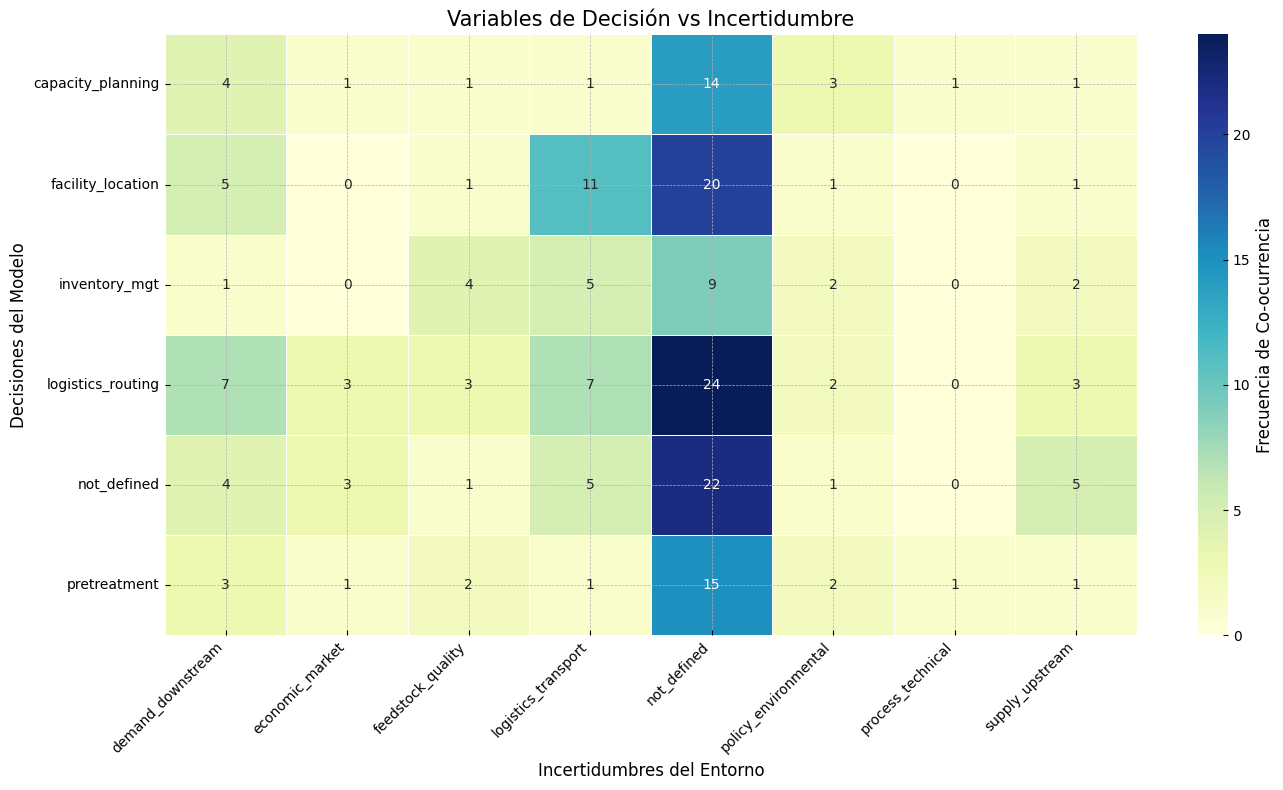

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(
    matriz_dec_inc,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Frecuencia de Co-ocurrencia'}
)

plt.title("Variables de Decisión vs Incertidumbre", fontsize=15)
plt.ylabel("Decisiones del Modelo", fontsize=12)
plt.xlabel("Incertidumbres del Entorno", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [99]:

orden_decisiones = [
    "capacity_planning",   # Estratégico (Inversión)
    "facility_location",  # Estratégico (Diseño de red)
    "inventory_mgt",      # Táctico (Gestión de stocks)
    "pretreatment",       # Táctico/Técnico (Procesamiento)
    "logistics_routing"   # Operativo (Movimiento)
]

matriz_filtrada = matriz_dec_inc.copy()

if 'not_defined' in matriz_filtrada.index:
    matriz_filtrada = matriz_filtrada.drop(index='not_defined')
if 'not_defined' in matriz_filtrada.columns:
    matriz_filtrada = matriz_filtrada.drop(columns='not_defined')

orden_final = [d for d in orden_decisiones if d in matriz_filtrada.index]
matriz_filtrada = matriz_filtrada.reindex(orden_final)

print("Matriz filtrada y jerarquizada lista.")

Matriz filtrada y jerarquizada lista.


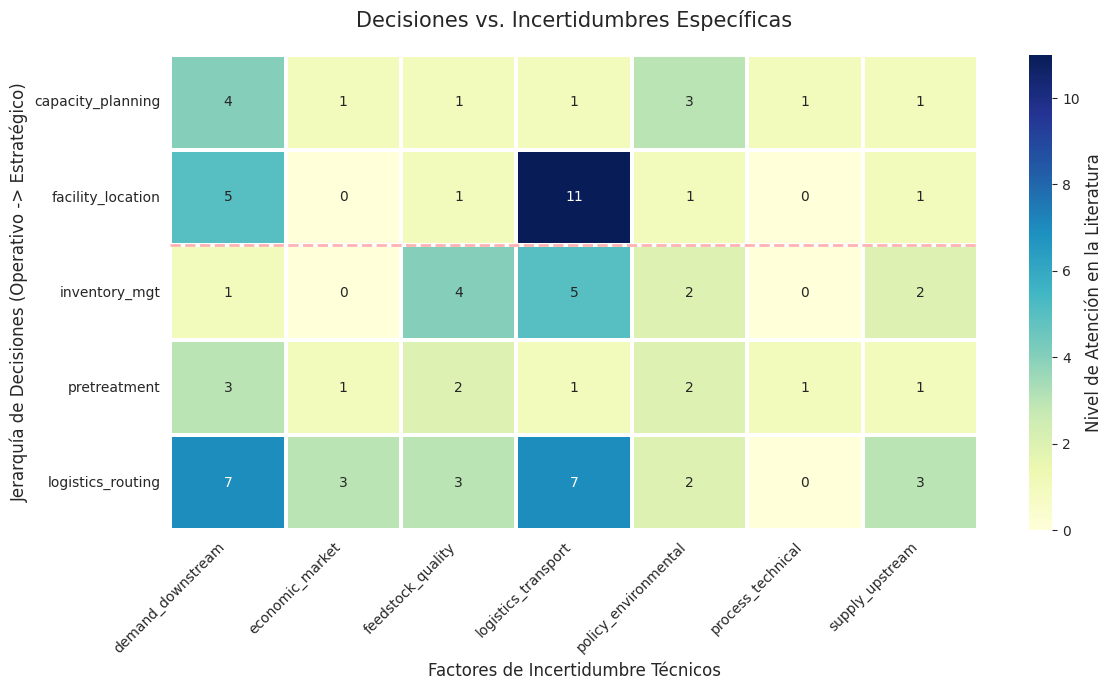

In [100]:
plt.figure(figsize=(12, 7))
sns.set_style("white")

ax = sns.heatmap(
    matriz_filtrada,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': 'Nivel de Atención en la Literatura'}
)

plt.axhline(y=2, color='red', linestyle='--', alpha=0.3, label="División Estratégica/Táctica")

plt.title("Decisiones vs. Incertidumbres Específicas", fontsize=15, pad=20)
plt.ylabel("Jerarquía de Decisiones (Operativo -> Estratégico)", fontsize=12)
plt.xlabel("Factores de Incertidumbre Técnicos", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [111]:
# 3. Procesamos el DataFrame (usando bibfile.data)
df_matrix = bibfile.data.copy()
df_matrix['found_apps'] = df_matrix['abstract'].apply(lambda x: check_presence(x, applications))
df_matrix['found_opts'] = df_matrix['abstract'].apply(lambda x: check_presence(x, optimization_methods))

# 4. Creamos la matriz de co-ocurrencia
heatmap_data = pd.DataFrame(0, index=applications.keys(), columns=optimization_methods.keys())

for _, row in df_matrix.iterrows():
    for app in row['found_apps']:
        for opt in row['found_opts']:
            heatmap_data.loc[app, opt] += 1

# 5. Graficamos el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Número de Artículos'})
plt.title('Matriz de Brechas: Aplicación vs. Método de Optimización', fontsize=15)
plt.xlabel('Métodos de Optimización', fontsize=12)
plt.ylabel('Eslabón de la Cadena (Aplicación)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

NameError: name 'check_presence' is not defined

In [101]:
!pip install networkx
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.6 MB/s eta 0:00:00


In [102]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [103]:
G = nx.Graph()

for _, row in df_matrix_completa.iterrows():

    method = row["method"]
    uncertainty = row["uncertainty"]
    application = row["application"]

    G.add_edge(method, uncertainty)
    G.add_edge(uncertainty, application)

In [104]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 20
Edges: 67


In [107]:
node_colors = []

for node in G.nodes():

    if node in optimization_models:
        node_colors.append("red")

    elif node in uncertainty_categories:
        node_colors.append("blue")

    else:
        node_colors.append("green")

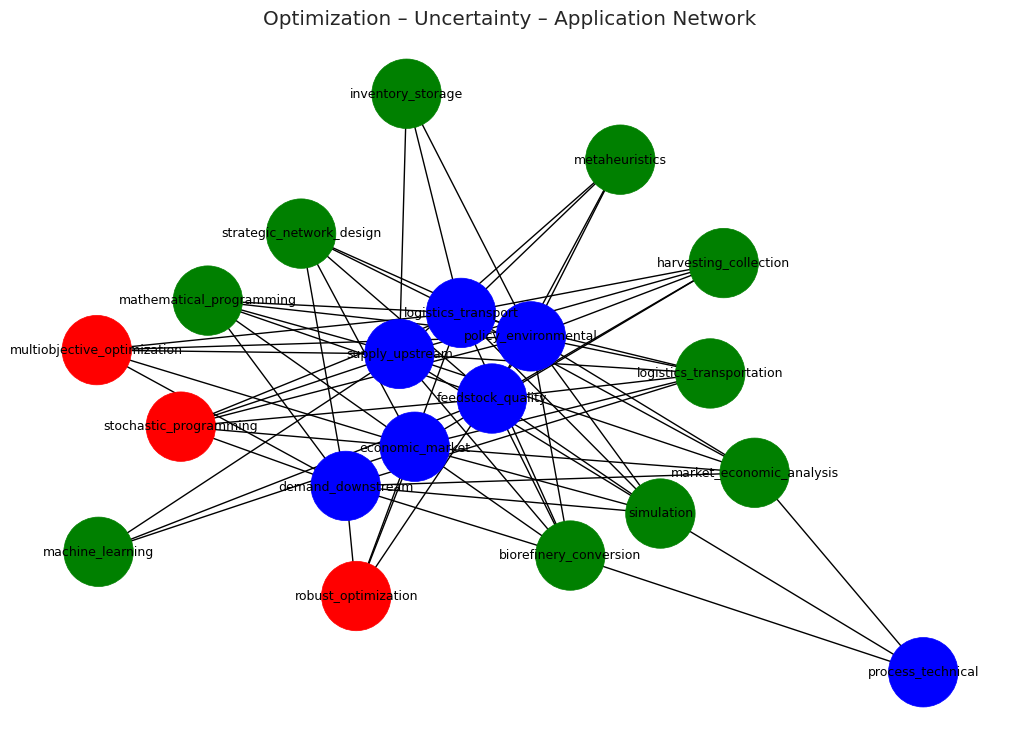

In [108]:
plt.figure(figsize=(10,7))

pos = nx.spring_layout(G, k=0.6)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    node_size=2500,
    with_labels=True,
    font_size=9
)

plt.title("Optimization – Uncertainty – Application Network")

plt.show()

In [109]:
centrality = nx.degree_centrality(G)

sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('policy_environmental', 0.631578947368421),
 ('logistics_transport', 0.631578947368421),
 ('economic_market', 0.5789473684210527),
 ('supply_upstream', 0.5789473684210527),
 ('demand_downstream', 0.47368421052631576),
 ('feedstock_quality', 0.47368421052631576),
 ('biorefinery_conversion', 0.3684210526315789),
 ('simulation', 0.3684210526315789),
 ('stochastic_programming', 0.3157894736842105),
 ('logistics_transportation', 0.3157894736842105)]

In [110]:
print(df_matrix_completa[['method', 'uncertainty', 'application']].isnull().sum())

method         0
uncertainty    0
application    0
dtype: int64


In [ ]:
print(len(df_matrix_completa))

1427
